<a href="https://colab.research.google.com/github/SyChen94/RidgeInfer/blob/main/ABIDE_SPD_Revised_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Revised ABIDE metric-space conditional-independence analysis

This notebook separates validation from scientific analysis and uses a fixed Monte Carlo subset of pooled integration pairs to reduce runtime. The same pair subset is held fixed for the observed statistic and every calibration replicate.

1. **Null-calibration gate:** compare local metric permutation with exact conditional resampling under a known conditional-independence null.
2. **Semi-synthetic power:** use a smooth low-rank ABIDE-grounded DGM as the primary design and retain the random-forest DGM as a stress test.
3. **Repeated-cross-fit real-data analysis:** stabilize the diagnosis analysis across prespecified balanced splits and aggregate split-level p-values by a fixed quantile rule.

Use a GPU runtime. Run the quick neighborhood screening first, freeze `SELECTED_K`, and then run only the selected local calibration and exact benchmark.

In [1]:
# Nilearn is the only nonstandard dependency in a normal Colab runtime.
!pip -q install nilearn==0.11.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 90.8 MB/s eta 0:00:00


## Reproducible implementation

The next cell downloads quality-checked NYU ABIDE-PCP AAL time series, constructs the SPD objects, implements generator-assisted MDF statistics, and provides both local-permutation and exact conditional-resampling calibration. It also implements smooth low-rank and random-forest construction DGMs, matching diagnostics, and repeated cross-fitting.

In [2]:
"""Revised Colab workflow for the ABIDE metric-space CI application.

The workflow separates three empirical goals: a diagnosis-related primary
analysis, a fully metric-object secondary analysis, and ABIDE-grounded
semi-synthetic null/alternative controls with known conditional-independence
status. Network definitions and analysis choices are fixed below and are not
selected using test p-values.
"""

from __future__ import annotations

import importlib.util
import json
import math
import subprocess
import sys
import time
from dataclasses import asdict, dataclass, replace
from pathlib import Path

if importlib.util.find_spec("nilearn") is None:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "nilearn==0.11.1"]
    )

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from nilearn.datasets import fetch_abide_pcp
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist, pdist
from sklearn.ensemble import RandomForestRegressor
from sklearn.covariance import LedoitWolf
from sklearn.linear_model import LogisticRegressionCV, RidgeCV
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.model_selection import KFold, ShuffleSplit, train_test_split
from sklearn.preprocessing import StandardScaler


ROI = {
    "motor": [0, 1, 18, 19, 56, 57],
    "visual": [42, 43, 44, 45, 46, 47],
    "audit": [78, 79, 80, 81],
    "dmn_post": [34, 35, 64, 65, 66, 67],
    "dmn_ant": [22, 23, 30, 31],
}

# A priori AAL-116 subsets for the fully metric-object secondary analysis.
# Indices are zero based. The salience set is best interpreted as an
# AAL-derived cingulo-opercular/salience proxy rather than a canonical atlas.
SECONDARY_ROI = {
    "dmn": [22, 23, 30, 31, 34, 35, 64, 65, 66, 67],
    "executive": [6, 7, 12, 13, 58, 59, 60, 61],
    "salience": [16, 17, 28, 29, 32, 33],
}

MACRO_NETWORK_ORDER = ["visual", "motor", "audit", "dmn_post", "dmn_ant"]

META_COLUMNS = [
    "SUB_ID",
    "FILE_ID",
    "DX_GROUP",
    "AGE_AT_SCAN",
    "SEX",
    "SITE_ID",
    "func_mean_fd",
]


@dataclass
class AnalysisConfig:
    site: str = "NYU"
    min_timepoints: int = 100
    max_mean_fd: float = 0.2
    ridge_spd: float = 1e-4
    analysis_fraction: float = 0.5
    split_seed: int = 20260905
    permutation_seed: int = 20260906
    generator_seed: int = 20260907
    integration_seed: int = 20260908
    include_diagnosis_in_z: bool = True
    primary_male_only: bool = True
    primary_include_global_connectivity: bool = False
    covariate_weight: float = 1.0
    k_neighbors: int = 10
    permutation_strategy: str = "min_cost"
    permutation_distance_weight: float = 0.05
    split_candidates: int = 512
    quick_mode: bool = True
    m_profile_quick: int = 30
    b_permutation_quick: int = 49
    m_profile_paper: int = 150
    b_permutation_paper: int = 999
    semi_repetitions_quick: int = 5
    semi_repetitions_paper: int = 50
    semi_permutations_quick: int = 49
    semi_permutations_paper: int = 150
    semi_shared_rank: int = 5
    semi_dgm_mean_rank: int = 5
    crossfit_repetitions_quick: int = 2
    crossfit_repetitions_paper: int = 10
    crossfit_quantile: float = 0.5
    save_all_crossfit_fold_plots: bool = False
    pair_batch_size: int = 512
    max_integration_pairs_quick: int = 2048
    max_integration_pairs_paper: int = 4096
    output_dir: str = "/content/abide_spd_revised_output"
    nilearn_data_dir: str = "/content/nilearn_data"

    @property
    def m_profile(self) -> int:
        return self.m_profile_quick if self.quick_mode else self.m_profile_paper

    @property
    def b_permutation(self) -> int:
        return (
            self.b_permutation_quick
            if self.quick_mode
            else self.b_permutation_paper
        )

    @property
    def crossfit_repetitions(self) -> int:
        return (
            self.crossfit_repetitions_quick
            if self.quick_mode
            else self.crossfit_repetitions_paper
        )

    @property
    def max_integration_pairs(self) -> int:
        return (
            self.max_integration_pairs_quick
            if self.quick_mode
            else self.max_integration_pairs_paper
        )


CONFIG = AnalysisConfig()


def regularize_spd(matrix: np.ndarray, ridge: float, correlation: bool) -> np.ndarray:
    matrix = np.asarray(matrix, dtype=np.float64)
    matrix = 0.5 * (matrix + matrix.T)
    p = matrix.shape[0]
    target_scale = 1.0 if correlation else float(np.trace(matrix) / p)
    if not np.isfinite(target_scale) or target_scale <= 0:
        raise ValueError("The covariance scale must be finite and positive.")
    return (1.0 - ridge) * matrix + ridge * target_scale * np.eye(p)


def network_matrix(
    timeseries: np.ndarray,
    columns: list[int],
    kind: str,
    ridge: float,
) -> np.ndarray:
    values = timeseries[:, columns]
    if kind == "correlation":
        return regularize_spd(
            np.corrcoef(values, rowvar=False), ridge=ridge, correlation=True
        )
    if kind == "covariance":
        return regularize_spd(
            np.cov(values, rowvar=False, ddof=1),
            ridge=ridge,
            correlation=False,
        )
    raise ValueError("kind must be 'correlation' or 'covariance'.")


def build_network_objects(
    subjects: list[np.ndarray],
    columns: list[int],
    kind: str,
    ridge: float,
) -> np.ndarray:
    objects = np.stack(
        [network_matrix(ts, columns, kind=kind, ridge=ridge) for ts in subjects]
    )
    minimum_eigenvalues = np.linalg.eigvalsh(objects).min(axis=1)
    if not np.all(np.isfinite(minimum_eigenvalues)) or minimum_eigenvalues.min() <= 0:
        raise ValueError(
            f"Invalid {kind} SPD object; minimum eigenvalue is "
            f"{minimum_eigenvalues.min()}."
        )
    return objects


def connectivity_summary(
    timeseries: np.ndarray,
    excluded_columns: set[int] | None = None,
) -> tuple[float, float]:
    excluded_columns = excluded_columns or set()
    keep = np.asarray(
        [j for j in range(timeseries.shape[1]) if j not in excluded_columns],
        dtype=np.int64,
    )
    values = timeseries[:, keep]
    standard_deviations = np.std(values, axis=0, ddof=1)
    valid = np.isfinite(standard_deviations) & (standard_deviations > 1e-8)
    values = values[:, valid]
    if values.shape[1] < 2:
        raise ValueError("Too few nonconstant ROIs for connectivity summary.")
    correlation = np.corrcoef(values, rowvar=False)
    upper = correlation[np.triu_indices(correlation.shape[0], k=1)]
    return float(np.mean(upper)), float(np.mean(np.abs(upper)))


def macro_network_matrix(timeseries: np.ndarray, ridge: float) -> np.ndarray:
    """Construct a low-dimensional SPD matrix of between-network coupling."""
    network_signals = []
    for name in MACRO_NETWORK_ORDER:
        values = np.asarray(timeseries[:, ROI[name]], dtype=np.float64)
        values = values - values.mean(axis=0, keepdims=True)
        scale = values.std(axis=0, ddof=1, keepdims=True)
        if np.any(~np.isfinite(scale)) or np.any(scale <= 1e-8):
            raise ValueError(f"A constant ROI was found in macro network {name}.")
        network_signals.append((values / scale).mean(axis=1))
    signals = np.column_stack(network_signals)
    return regularize_spd(
        np.corrcoef(signals, rowvar=False), ridge=ridge, correlation=True
    )


def download_and_build(config: AnalysisConfig) -> tuple[dict[str, np.ndarray], pd.DataFrame]:
    print("Downloading or loading cached ABIDE-PCP NYU AAL time series...")
    data = fetch_abide_pcp(
        data_dir=config.nilearn_data_dir,
        derivatives=["rois_aal"],
        pipeline="cpac",
        band_pass_filtering=True,
        global_signal_regression=False,
        quality_checked=True,
        n_subjects=None,
        SITE_ID=config.site,
    )
    phenotype = data.phenotypic.reset_index(drop=True)
    time_series = list(data.rois_aal)
    if len(phenotype) != len(time_series):
        raise RuntimeError("Phenotype and ROI time-series rows are not aligned.")

    required_columns = sorted(
        {
            j
            for columns in list(ROI.values()) + list(SECONDARY_ROI.values())
            for j in columns
        }
    )
    maximum_column = max(required_columns)
    numeric_fd = pd.to_numeric(phenotype["func_mean_fd"], errors="coerce")
    kept_indices: list[int] = []
    subjects: list[np.ndarray] = []
    exclusions = {
        "short_or_missing": 0,
        "invalid_shape": 0,
        "motion": 0,
        "nonfinite": 0,
        "constant_required_roi": 0,
    }

    for index, raw in enumerate(time_series):
        if raw is None or raw.shape[0] < config.min_timepoints:
            exclusions["short_or_missing"] += 1
            continue
        values = np.asarray(raw, dtype=np.float64)
        if values.ndim != 2 or values.shape[1] <= maximum_column:
            exclusions["invalid_shape"] += 1
            continue
        fd = numeric_fd.iloc[index]
        if not np.isfinite(fd) or fd >= config.max_mean_fd:
            exclusions["motion"] += 1
            continue
        if not np.all(np.isfinite(values)):
            exclusions["nonfinite"] += 1
            continue
        required_sd = np.std(values[:, required_columns], axis=0, ddof=1)
        if np.any(required_sd <= 1e-8):
            exclusions["constant_required_roi"] += 1
            continue
        kept_indices.append(index)
        subjects.append(values)

    if not subjects:
        raise RuntimeError("No subjects remain after quality control.")

    available_meta = [column for column in META_COLUMNS if column in phenotype.columns]
    metadata = phenotype.loc[kept_indices, available_meta].reset_index(drop=True)
    metadata["func_mean_fd"] = numeric_fd.iloc[kept_indices].to_numpy()
    metadata["n_timepoints"] = [ts.shape[0] for ts in subjects]

    negative_targets = set(ROI["visual"] + ROI["motor"])
    positive_targets = set(ROI["dmn_post"] + ROI["dmn_ant"])
    overall = [connectivity_summary(ts) for ts in subjects]
    negative = [connectivity_summary(ts, negative_targets) for ts in subjects]
    positive = [connectivity_summary(ts, positive_targets) for ts in subjects]
    metadata["global_connectivity_mean"] = [item[0] for item in overall]
    metadata["global_connectivity_abs_mean"] = [item[1] for item in overall]
    metadata["global_connectivity_neg_excluded_abs_mean"] = [
        item[1] for item in negative
    ]
    metadata["global_connectivity_pos_excluded_abs_mean"] = [
        item[1] for item in positive
    ]

    secondary_targets = set(
        SECONDARY_ROI["dmn"] + SECONDARY_ROI["executive"]
    )
    secondary_global = [
        connectivity_summary(ts, secondary_targets) for ts in subjects
    ]
    metadata["global_connectivity_secondary_excluded_abs_mean"] = [
        item[1] for item in secondary_global
    ]

    correlation = {
        name: build_network_objects(
            subjects, columns, kind="correlation", ridge=config.ridge_spd
        )
        for name, columns in ROI.items()
    }
    covariance = {
        name: build_network_objects(
            subjects, columns, kind="covariance", ridge=config.ridge_spd
        )
        for name, columns in ROI.items()
    }
    secondary = {
        name: build_network_objects(
            subjects, columns, kind="correlation", ridge=config.ridge_spd
        )
        for name, columns in SECONDARY_ROI.items()
    }
    macro = np.stack(
        [macro_network_matrix(ts, ridge=config.ridge_spd) for ts in subjects]
    )
    arrays = {
        "Xn": correlation["visual"],
        "Yn": correlation["motor"],
        "Zn": correlation["audit"],
        "Xp": correlation["dmn_post"],
        "Yp": correlation["dmn_ant"],
        "Zp": correlation["visual"],
        "Xn_cov": covariance["visual"],
        "Yn_cov": covariance["motor"],
        "Zn_cov": covariance["audit"],
        "Xp_cov": covariance["dmn_post"],
        "Yp_cov": covariance["dmn_ant"],
        "Zp_cov": covariance["visual"],
        "X_diagnosis": macro,
        "X_secondary": secondary["dmn"],
        "Y_secondary": secondary["executive"],
        "Z_secondary": secondary["salience"],
    }

    output_dir = Path(config.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        output_dir / "abide_spd_ci.npz",
        **arrays,
        subject_ids=metadata["SUB_ID"].to_numpy(),
        primary_representation=np.asarray("correlation"),
        ridge=np.asarray(config.ridge_spd),
    )
    metadata.to_csv(output_dir / "abide_spd_subjects.csv", index=False)
    print(f"Retained n={len(subjects)}; exclusions={exclusions}")
    print(f"Saved data to {output_dir}")
    return arrays, metadata


def matrix_log_vectors(matrices: np.ndarray, eps: float = 1e-10) -> np.ndarray:
    """Vectorize matrix logs so Euclidean distance equals Frobenius distance."""
    matrices = np.asarray(matrices, dtype=np.float64)
    eigenvalues, eigenvectors = np.linalg.eigh(matrices)
    eigenvalues = np.maximum(eigenvalues, eps)
    log_matrices = (
        eigenvectors * np.log(eigenvalues)[..., None, :]
    ) @ np.swapaxes(eigenvectors, -1, -2)
    p = matrices.shape[-1]
    row, column = np.tril_indices(p)
    weights = np.where(row == column, 1.0, np.sqrt(2.0))
    return log_matrices[:, row, column] * weights


def positive_median_distance(values: np.ndarray) -> float:
    distances = pdist(values, metric="euclidean")
    distances = distances[np.isfinite(distances) & (distances > 0)]
    return float(np.median(distances)) if distances.size else 1.0


def _numeric_with_training_imputation(
    series: pd.Series,
    training_indices: np.ndarray,
) -> np.ndarray:
    values = pd.to_numeric(series, errors="coerce").to_numpy(dtype=np.float64)
    median = np.nanmedian(values[training_indices])
    values[~np.isfinite(values)] = median
    return values


def condition_features(
    z_spd: np.ndarray,
    metadata: pd.DataFrame,
    training_indices: np.ndarray,
    global_column: str,
    config: AnalysisConfig,
) -> tuple[np.ndarray, list[str], dict[str, float]]:
    z_vectors = matrix_log_vectors(z_spd)
    z_scale = positive_median_distance(z_vectors[training_indices])
    z_block = z_vectors / z_scale

    continuous_names = [
        "age",
        "mean_fd",
        "log_timepoints",
        "global_connectivity",
    ]
    age = _numeric_with_training_imputation(metadata["AGE_AT_SCAN"], training_indices)
    mean_fd = _numeric_with_training_imputation(
        metadata["func_mean_fd"], training_indices
    )
    timepoints = _numeric_with_training_imputation(
        metadata["n_timepoints"], training_indices
    )
    global_connectivity = _numeric_with_training_imputation(
        metadata[global_column], training_indices
    )
    continuous = np.column_stack(
        [age, mean_fd, np.log(np.maximum(timepoints, 1.0)), global_connectivity]
    )
    scaler = StandardScaler().fit(continuous[training_indices])
    covariates = [scaler.transform(continuous)]

    sex = _numeric_with_training_imputation(metadata["SEX"], training_indices)
    covariates.append((sex == 2).astype(np.float64)[:, None])
    covariate_names = continuous_names + ["sex_2"]
    if config.include_diagnosis_in_z:
        diagnosis = _numeric_with_training_imputation(
            metadata["DX_GROUP"], training_indices
        )
        covariates.append((diagnosis == 2).astype(np.float64)[:, None])
        covariate_names.append("diagnosis_2")

    covariate_block = np.concatenate(covariates, axis=1)
    covariate_scale = positive_median_distance(covariate_block[training_indices])
    covariate_block = config.covariate_weight * covariate_block / covariate_scale
    features = np.concatenate([z_block, covariate_block], axis=1)
    labels = [f"log_spd_{j}" for j in range(z_block.shape[1])] + covariate_names
    scales = {
        "z_spd_median_distance": z_scale,
        "covariate_median_distance": covariate_scale,
    }
    return features, labels, scales


def mixed_condition_features(
    metadata: pd.DataFrame,
    training_indices: np.ndarray,
    config: AnalysisConfig,
    z_spd: np.ndarray | None = None,
    include_sex: bool = True,
    include_diagnosis: bool = False,
    include_global: bool = False,
    global_column: str = "global_connectivity_abs_mean",
) -> tuple[np.ndarray, list[str], dict[str, float]]:
    """Build a train-scaled product-metric representation of mixed Z."""
    continuous_values = []
    continuous_names = []
    candidate_columns = [
        ("AGE_AT_SCAN", "age", False),
        ("func_mean_fd", "mean_fd", False),
        ("n_timepoints", "log_timepoints", True),
    ]
    if include_global:
        candidate_columns.append((global_column, "global_connectivity", False))

    for column, label, take_log in candidate_columns:
        values = _numeric_with_training_imputation(
            metadata[column], training_indices
        )
        if take_log:
            values = np.log(np.maximum(values, 1.0))
        if np.std(values[training_indices]) <= 1e-10:
            continue
        continuous_values.append(values)
        continuous_names.append(label)

    blocks = []
    labels = []
    scales: dict[str, float] = {}
    if z_spd is not None:
        z_vectors = matrix_log_vectors(z_spd)
        z_scale = positive_median_distance(z_vectors[training_indices])
        blocks.append(z_vectors / z_scale)
        labels.extend([f"log_spd_{j}" for j in range(z_vectors.shape[1])])
        scales["z_spd_median_distance"] = z_scale

    covariate_blocks = []
    covariate_names = []
    if continuous_values:
        continuous = np.column_stack(continuous_values)
        scaler = StandardScaler().fit(continuous[training_indices])
        covariate_blocks.append(scaler.transform(continuous))
        covariate_names.extend(continuous_names)
    if include_sex:
        sex = _numeric_with_training_imputation(metadata["SEX"], training_indices)
        covariate_blocks.append((sex == 2).astype(np.float64)[:, None])
        covariate_names.append("sex_2")
    if include_diagnosis:
        diagnosis = _numeric_with_training_imputation(
            metadata["DX_GROUP"], training_indices
        )
        covariate_blocks.append((diagnosis == 2).astype(np.float64)[:, None])
        covariate_names.append("diagnosis_2")

    if not covariate_blocks:
        raise ValueError("At least one conditioning covariate is required.")
    covariates = np.concatenate(covariate_blocks, axis=1)
    covariate_scale = positive_median_distance(covariates[training_indices])
    covariates = config.covariate_weight * covariates / covariate_scale
    blocks.append(covariates)
    labels.extend(covariate_names)
    scales["covariate_median_distance"] = covariate_scale
    return np.concatenate(blocks, axis=1), labels, scales


def split_balance_features(
    metadata: pd.DataFrame,
    indices: np.ndarray,
    include_sex: bool,
    include_diagnosis: bool,
    include_global: bool,
    global_column: str = "global_connectivity_abs_mean",
    z_spd: np.ndarray | None = None,
) -> np.ndarray:
    """Features used only to balance folds, never to select test results."""
    blocks = [
        pd.to_numeric(metadata["AGE_AT_SCAN"], errors="coerce").to_numpy()[:, None],
        pd.to_numeric(metadata["func_mean_fd"], errors="coerce").to_numpy()[:, None],
    ]
    if include_global:
        blocks.append(
            pd.to_numeric(metadata[global_column], errors="coerce").to_numpy()[:, None]
        )
    if include_sex:
        blocks.append((metadata["SEX"].to_numpy() == 2).astype(float)[:, None])
    if include_diagnosis:
        blocks.append(
            (metadata["DX_GROUP"].to_numpy() == 2).astype(float)[:, None]
        )
    if z_spd is not None:
        blocks.append(matrix_log_vectors(z_spd))
    features = np.concatenate(blocks, axis=1)[indices]
    medians = np.nanmedian(features, axis=0)
    missing = ~np.isfinite(features)
    features[missing] = np.take(medians, np.where(missing)[1])
    return StandardScaler().fit_transform(features)


def balanced_two_folds(
    indices: np.ndarray,
    balance_features: np.ndarray,
    config: AnalysisConfig,
    class_labels: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray, dict[str, float]]:
    """Choose a reproducible split balanced globally and within fixed classes."""
    splitter = ShuffleSplit(
        n_splits=config.split_candidates,
        test_size=config.analysis_fraction,
        random_state=config.split_seed,
    )
    if class_labels is not None:
        class_labels = np.asarray(class_labels).reshape(-1)
        if len(class_labels) != len(indices):
            raise ValueError("class_labels must align with indices.")
    best: tuple[
        float,
        np.ndarray,
        np.ndarray,
        np.ndarray,
        float,
        float,
    ] | None = None
    for training_local, analysis_local in splitter.split(balance_features):
        global_difference = np.abs(
            balance_features[training_local].mean(axis=0)
            - balance_features[analysis_local].mean(axis=0)
        )
        score_components = [global_difference]
        within_class_max = 0.0
        class_proportion_max = 0.0
        if class_labels is not None:
            labels = np.unique(class_labels)
            class_differences = []
            admissible = True
            for label in labels:
                training_class = training_local[class_labels[training_local] == label]
                analysis_class = analysis_local[class_labels[analysis_local] == label]
                if (
                    len(training_class) < 5
                    or len(analysis_class) < 5
                    or abs(len(training_class) - len(analysis_class)) > 2
                ):
                    admissible = False
                    break
                difference = np.abs(
                    balance_features[training_class].mean(axis=0)
                    - balance_features[analysis_class].mean(axis=0)
                )
                class_differences.append(difference)
                class_proportion_max = max(
                    class_proportion_max,
                    abs(
                        len(training_class) / len(training_local)
                        - len(analysis_class) / len(analysis_local)
                    ),
                )
            if not admissible:
                continue
            stacked_class_differences = np.concatenate(class_differences)
            score_components.append(stacked_class_differences)
            score_components.append(np.asarray([class_proportion_max]))
            within_class_max = float(np.max(stacked_class_differences))
        all_differences = np.concatenate(score_components)
        score = float(np.sqrt(np.mean(all_differences**2)))
        if best is None or score < best[0]:
            best = (
                score,
                training_local,
                analysis_local,
                global_difference,
                within_class_max,
                class_proportion_max,
            )
    if best is None:
        raise RuntimeError("No admissible balanced split was found.")
    (
        score,
        training_local,
        analysis_local,
        global_difference,
        within_class_max,
        class_proportion_max,
    ) = best
    diagnostics = {
        "balance_rms_smd": score,
        "balance_max_smd": float(np.max(global_difference)),
        "balance_within_class_max_smd": within_class_max,
        "balance_class_proportion_max_diff": class_proportion_max,
    }
    return indices[training_local], indices[analysis_local], diagnostics


class ConditionalGaussianGenerator:
    """Ridge conditional mean plus a shrinkage Gaussian residual law."""

    def __init__(self) -> None:
        self.z_scaler = StandardScaler()
        self.x_scaler = StandardScaler()
        self.regression = RidgeCV(alphas=np.logspace(-2, 3, 16))
        self.residual_covariance: np.ndarray | None = None

    def fit(self, z: np.ndarray, x: np.ndarray) -> "ConditionalGaussianGenerator":
        z_scaled = self.z_scaler.fit_transform(z)
        x_scaled = self.x_scaler.fit_transform(x)
        self.regression.fit(z_scaled, x_scaled)
        residuals = x_scaled - self.regression.predict(z_scaled)
        self.residual_covariance = LedoitWolf().fit(residuals).covariance_
        return self

    def mean(self, z: np.ndarray) -> np.ndarray:
        prediction = self.regression.predict(self.z_scaler.transform(z))
        return self.x_scaler.inverse_transform(prediction)

    def sample(
        self,
        z: np.ndarray,
        draws: int,
        rng: np.random.Generator,
    ) -> np.ndarray:
        if self.residual_covariance is None:
            raise RuntimeError("The generator must be fitted before sampling.")
        z_scaled = self.z_scaler.transform(z)
        mean_scaled = self.regression.predict(z_scaled)
        noise = rng.multivariate_normal(
            mean=np.zeros(mean_scaled.shape[1]),
            cov=self.residual_covariance,
            size=(len(z), draws),
        )
        generated_scaled = mean_scaled[:, None, :] + noise
        flat = generated_scaled.reshape(-1, generated_scaled.shape[-1])
        return self.x_scaler.inverse_transform(flat).reshape(generated_scaled.shape)


class ConditionalBernoulliGenerator:
    """Logistic conditional generator for a binary metric response."""

    def __init__(self) -> None:
        self.z_scaler = StandardScaler()
        self.model = LogisticRegressionCV(
            Cs=np.logspace(-2, 2, 9),
            cv=5,
            scoring="neg_log_loss",
            solver="lbfgs",
            max_iter=5000,
        )

    def fit(self, z: np.ndarray, y: np.ndarray) -> "ConditionalBernoulliGenerator":
        z_scaled = self.z_scaler.fit_transform(z)
        self.model.fit(z_scaled, np.asarray(y).reshape(-1).astype(int))
        return self

    def mean(self, z: np.ndarray) -> np.ndarray:
        probability = self.model.predict_proba(self.z_scaler.transform(z))[:, 1]
        return probability[:, None]

    def sample(
        self,
        z: np.ndarray,
        draws: int,
        rng: np.random.Generator,
    ) -> np.ndarray:
        probability = self.mean(z).reshape(-1, 1)
        values = rng.binomial(1, probability, size=(len(z), draws))
        return values.astype(np.float64)[..., None]


def local_bijection(
    z_distance: np.ndarray,
    k: int,
    rng: np.random.Generator,
) -> tuple[np.ndarray, int]:
    """Random-priority local assignment with nearest-available fallback."""
    n = z_distance.shape[0]
    if not 1 <= k < n:
        raise ValueError(f"k must be between 1 and n-1; received k={k}, n={n}.")
    distance = z_distance.copy()
    np.fill_diagonal(distance, np.inf)
    neighbors = np.argsort(distance, axis=1)[:, :k]
    priority_order = rng.permutation(n)
    rank = np.empty(n, dtype=np.int64)
    rank[priority_order] = np.arange(n)
    available = np.ones(n, dtype=bool)
    assignment = np.empty(n, dtype=np.int64)
    fallback_count = 0

    for target in range(n):
        feasible = neighbors[target][available[neighbors[target]]]
        if feasible.size:
            selected = feasible[np.argmin(rank[feasible])]
        else:
            fallback_count += 1
            candidates = np.flatnonzero(available)
            selected = candidates[np.argmin(distance[target, candidates])]
        assignment[target] = selected
        available[selected] = False
    if np.unique(assignment).size != n:
        raise RuntimeError("Local assignment is not a bijection.")
    return assignment, fallback_count


def local_bijection_min_cost(
    z_distance: np.ndarray,
    k: int,
    rng: np.random.Generator,
    distance_weight: float = 0.05,
) -> tuple[np.ndarray, int]:
    """Randomized minimum-cost local matching with a one-to-one assignment."""
    n = z_distance.shape[0]
    if not 1 <= k < n:
        raise ValueError(f"k must be between 1 and n-1; received k={k}, n={n}.")
    distance = np.asarray(z_distance, dtype=np.float64).copy()
    finite = distance[np.isfinite(distance) & (distance > 0)]
    scale = float(np.median(finite)) if finite.size else 1.0
    normalized = distance / scale
    np.fill_diagonal(normalized, 1e9)
    neighbors = np.argsort(normalized, axis=1)[:, :k]
    allowed = np.zeros((n, n), dtype=bool)
    allowed[np.arange(n)[:, None], neighbors] = True

    # Random edge costs produce different local bijections; the small distance
    # term favors closer donors without making the assignment deterministic.
    cost = rng.random((n, n)) + distance_weight * normalized
    cost[~allowed] = 1e6 + normalized[~allowed]
    np.fill_diagonal(cost, 1e9)
    rows, columns = linear_sum_assignment(cost)
    assignment = np.empty(n, dtype=np.int64)
    assignment[rows] = columns
    fallback_count = int(np.sum(~allowed[rows, columns]))
    if np.unique(assignment).size != n or np.any(assignment == np.arange(n)):
        raise RuntimeError("Minimum-cost local assignment is not a derangement.")
    return assignment, fallback_count


def prepare_xz_cache(
    x_observed: np.ndarray,
    x_profile: np.ndarray,
    x_copy: np.ndarray,
    z: np.ndarray,
    device: torch.device,
    pair_batch_size: int,
    max_integration_pairs: int,
    integration_seed: int,
) -> dict[str, torch.Tensor | int]:
    dtype = torch.float32
    x_observed_t = torch.as_tensor(x_observed, dtype=dtype, device=device)
    x_profile_t = torch.as_tensor(x_profile, dtype=dtype, device=device)
    x_copy_t = torch.as_tensor(x_copy, dtype=dtype, device=device)
    z_t = torch.as_tensor(z, dtype=dtype, device=device)
    n, m = x_profile.shape[:2]
    x_pool = torch.cat([x_observed_t, x_copy_t], dim=0)
    z_pool = torch.cat([z_t, z_t], dim=0)
    pooled_n = 2 * n

    dx_pool_pool = torch.cdist(x_pool, x_pool)
    dx_pool_observed = torch.cdist(x_pool, x_observed_t)
    dx_pool_profile = torch.cdist(
        x_pool, x_profile_t.reshape(n * m, -1)
    ).reshape(pooled_n, n, m)
    dz_pool_pool = torch.cdist(z_pool, z_pool)
    dz_pool_observed = torch.cdist(z_pool, z_t)

    first_numpy = np.repeat(np.arange(pooled_n), pooled_n)
    second_numpy = np.tile(np.arange(pooled_n), pooled_n)
    keep = first_numpy != second_numpy
    first_numpy = first_numpy[keep]
    second_numpy = second_numpy[keep]
    candidate_pair_count = len(first_numpy)
    if max_integration_pairs < 1:
        raise ValueError("max_integration_pairs must be positive.")
    if candidate_pair_count > max_integration_pairs:
        pair_rng = np.random.default_rng(integration_seed)
        selected = pair_rng.choice(
            candidate_pair_count,
            size=max_integration_pairs,
            replace=False,
        )
        first_numpy = first_numpy[selected]
        second_numpy = second_numpy[selected]
    first = torch.as_tensor(first_numpy, dtype=torch.long, device=device)
    second = torch.as_tensor(second_numpy, dtype=torch.long, device=device)
    pair_count = int(first.numel())
    joint_x = torch.empty((pair_count, n), dtype=torch.bool, device=device)
    profile_x = torch.empty((pair_count, n), dtype=dtype, device=device)
    joint_z = torch.empty((pair_count, n), dtype=torch.bool, device=device)

    for start in range(0, pair_count, pair_batch_size):
        stop = min(start + pair_batch_size, pair_count)
        a = first[start:stop]
        b = second[start:stop]
        radius_x = dx_pool_pool[a, b]
        radius_z = dz_pool_pool[a, b]
        joint_x[start:stop] = dx_pool_observed[a] <= radius_x[:, None]
        profile_x[start:stop] = (
            dx_pool_profile[a] <= radius_x[:, None, None]
        ).float().mean(dim=2)
        joint_z[start:stop] = dz_pool_observed[a] <= radius_z[:, None]

    return {
        "first": first,
        "second": second,
        "joint_x": joint_x,
        "profile_x": profile_x,
        "joint_z": joint_z,
        "n": n,
        "m": m,
        "pair_count": pair_count,
        "candidate_pair_count": candidate_pair_count,
        "pair_batch_size": pair_batch_size,
    }


@torch.no_grad()
def statistic_from_y(
    cache: dict[str, torch.Tensor | int],
    y_observed: np.ndarray,
    y_profile: np.ndarray,
    y_copy: np.ndarray,
    device: torch.device,
) -> float:
    dtype = torch.float32
    y_observed_t = torch.as_tensor(y_observed, dtype=dtype, device=device)
    y_profile_t = torch.as_tensor(y_profile, dtype=dtype, device=device)
    y_copy_t = torch.as_tensor(y_copy, dtype=dtype, device=device)
    n = int(cache["n"])
    m = int(cache["m"])
    pair_count = int(cache["pair_count"])
    batch_size = int(cache["pair_batch_size"])
    y_pool = torch.cat([y_observed_t, y_copy_t], dim=0)
    pooled_n = 2 * n
    dy_pool_pool = torch.cdist(y_pool, y_pool)
    dy_pool_observed = torch.cdist(y_pool, y_observed_t)
    dy_pool_profile = torch.cdist(
        y_pool, y_profile_t.reshape(n * m, -1)
    ).reshape(pooled_n, n, m)

    first = cache["first"]
    second = cache["second"]
    joint_x = cache["joint_x"]
    profile_x = cache["profile_x"]
    joint_z = cache["joint_z"]
    total = torch.zeros((), dtype=dtype, device=device)
    for start in range(0, pair_count, batch_size):
        stop = min(start + batch_size, pair_count)
        a = first[start:stop]
        b = second[start:stop]
        radius_y = dy_pool_pool[a, b]
        joint_y = dy_pool_observed[a] <= radius_y[:, None]
        profile_y = (
            dy_pool_profile[a] <= radius_y[:, None, None]
        ).float().mean(dim=2)
        z_float = joint_z[start:stop].float()
        joint_mdf = (
            joint_x[start:stop].float() * joint_y.float() * z_float
        ).mean(dim=1)
        factorized_mdf = (
            profile_x[start:stop] * profile_y * z_float
        ).mean(dim=1)
        total += torch.sum((joint_mdf - factorized_mdf) ** 2)
    return float((total / pair_count).cpu())


@torch.no_grad()
def prepare_generator_assisted_state(
    x_observed: np.ndarray,
    y_observed: np.ndarray,
    z: np.ndarray,
    x_generated: np.ndarray,
    y_generated: np.ndarray,
    config: AnalysisConfig,
) -> dict[str, object]:
    """Prepare the fixed statistic components shared by all calibrations."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    x_copy, x_profile = x_generated[:, 0], x_generated[:, 1:]
    y_copy, y_profile = y_generated[:, 0], y_generated[:, 1:]
    cache = prepare_xz_cache(
        x_observed,
        x_profile,
        x_copy,
        z,
        device=device,
        pair_batch_size=config.pair_batch_size,
        max_integration_pairs=config.max_integration_pairs,
        integration_seed=config.integration_seed,
    )
    observed = statistic_from_y(cache, y_observed, y_profile, y_copy, device)
    return {
        "device": device,
        "cache": cache,
        "observed": observed,
        "y_profile": y_profile,
        "y_copy": y_copy,
    }


def generator_assisted_test(
    x_observed: np.ndarray,
    y_observed: np.ndarray,
    z: np.ndarray,
    x_generated: np.ndarray,
    y_generated: np.ndarray,
    config: AnalysisConfig,
    verbose: bool = True,
    calibration_mode: str = "local_permutation",
    y_calibration_samples: np.ndarray | None = None,
    prepared_state: dict[str, object] | None = None,
) -> dict[str, object]:
    state = prepared_state or prepare_generator_assisted_state(
        x_observed,
        y_observed,
        z,
        x_generated,
        y_generated,
        config,
    )
    device = state["device"]
    cache = state["cache"]
    observed = float(state["observed"])
    y_profile = state["y_profile"]
    y_copy = state["y_copy"]
    permutation_statistics = np.empty(config.b_permutation, dtype=np.float64)
    fallback_counts = np.full(config.b_permutation, np.nan, dtype=np.float64)
    matched_distances = np.full(config.b_permutation, np.nan, dtype=np.float64)
    if calibration_mode == "local_permutation":
        z_distance = cdist(z, z, metric="euclidean")
        rng = np.random.default_rng(config.permutation_seed)
    elif calibration_mode == "oracle_resampling":
        if y_calibration_samples is None:
            raise ValueError(
                "oracle_resampling requires y_calibration_samples."
            )
        y_calibration_samples = np.asarray(
            y_calibration_samples, dtype=np.float64
        )
        expected_shape = (config.b_permutation,) + y_observed.shape
        if y_calibration_samples.shape != expected_shape:
            raise ValueError(
                "y_calibration_samples must have shape "
                f"{expected_shape}; received {y_calibration_samples.shape}."
            )
        z_distance = None
        rng = None
    else:
        raise ValueError(
            "calibration_mode must be 'local_permutation' or "
            "'oracle_resampling'."
        )
    start_time = time.time()
    for b in range(config.b_permutation):
        if calibration_mode == "oracle_resampling":
            y_calibrated = y_calibration_samples[b]
        else:
            if config.permutation_strategy == "greedy":
                assignment, fallback_count = local_bijection(
                    z_distance, k=config.k_neighbors, rng=rng
                )
            elif config.permutation_strategy == "min_cost":
                assignment, fallback_count = local_bijection_min_cost(
                    z_distance,
                    k=config.k_neighbors,
                    rng=rng,
                    distance_weight=config.permutation_distance_weight,
                )
            else:
                raise ValueError(
                    "permutation_strategy must be 'greedy' or 'min_cost'."
                )
            y_calibrated = y_observed[assignment]
            fallback_counts[b] = fallback_count
            matched_distances[b] = float(
                np.mean(z_distance[np.arange(len(z)), assignment])
            )
        permutation_statistics[b] = statistic_from_y(
            cache,
            y_calibrated,
            y_profile,
            y_copy,
            device,
        )
        if verbose and (b + 1) % max(1, config.b_permutation // 5) == 0:
            print(
                f"  completed {b + 1}/{config.b_permutation} "
                "calibration replicates"
            )
    p_value = float(
        (1 + np.sum(permutation_statistics >= observed))
        / (config.b_permutation + 1)
    )
    return {
        "T_obs": observed,
        "T_perm": permutation_statistics,
        "p_value": p_value,
        "reject_0.05": bool(p_value <= 0.05),
        "mean_fallback_fraction": (
            float(np.mean(fallback_counts) / len(z))
            if calibration_mode == "local_permutation"
            else float("nan")
        ),
        "mean_matched_z_distance": (
            float(np.mean(matched_distances))
            if calibration_mode == "local_permutation"
            else float("nan")
        ),
        "permutation_strategy": (
            config.permutation_strategy
            if calibration_mode == "local_permutation"
            else "not_applicable"
        ),
        "calibration_mode": calibration_mode,
        "integration_pairs": int(cache["pair_count"]),
        "candidate_integration_pairs": int(cache["candidate_pair_count"]),
        "elapsed_seconds": float(time.time() - start_time),
        "device": str(device),
    }


def save_diagnostics(
    arrays: dict[str, np.ndarray],
    metadata: pd.DataFrame,
    output_dir: Path,
) -> None:
    print("\nMetadata summary")
    columns = [
        "DX_GROUP",
        "AGE_AT_SCAN",
        "SEX",
        "func_mean_fd",
        "n_timepoints",
        "global_connectivity_abs_mean",
    ]
    print(metadata[columns].describe(include="all").T)
    records = []
    for key in ["Xn", "Yn", "Zn", "Xp", "Yp", "Zp"]:
        eigenvalues = np.linalg.eigvalsh(arrays[key])
        records.append(
            {
                "object": key,
                "dimension": arrays[key].shape[-1],
                "minimum_eigenvalue": float(eigenvalues.min()),
                "median_condition_number": float(
                    np.median(eigenvalues[:, -1] / eigenvalues[:, 0])
                ),
            }
        )
    diagnostics = pd.DataFrame(records)
    diagnostics.to_csv(output_dir / "spd_diagnostics.csv", index=False)
    print("\nSPD diagnostics")
    print(diagnostics.to_string(index=False))

    fig, axes = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
    for axis, key in zip(axes.ravel(), ["Xn", "Yn", "Zn", "Xp", "Yp", "Zp"]):
        image = axis.imshow(
            arrays[key].mean(axis=0),
            vmin=-0.2,
            vmax=1.0,
            cmap="RdBu_r",
            aspect="equal",
        )
        fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
        axis.set_title(f"{key}: mean correlation")
    fig.savefig(output_dir / "mean_network_correlations.png", dpi=180)
    plt.show()


def run_problem(
    name: str,
    x_spd: np.ndarray,
    y_spd: np.ndarray,
    z_spd: np.ndarray,
    metadata: pd.DataFrame,
    training_indices: np.ndarray,
    analysis_indices: np.ndarray,
    global_column: str,
    config: AnalysisConfig,
    output_dir: Path,
) -> dict[str, object]:
    print(f"\n{'=' * 72}\n{name}\n{'=' * 72}")
    x_vectors = matrix_log_vectors(x_spd)
    y_vectors = matrix_log_vectors(y_spd)
    z_features, _, scales = condition_features(
        z_spd,
        metadata,
        training_indices=training_indices,
        global_column=global_column,
        config=config,
    )
    x_generator = ConditionalGaussianGenerator().fit(
        z_features[training_indices], x_vectors[training_indices]
    )
    y_generator = ConditionalGaussianGenerator().fit(
        z_features[training_indices], y_vectors[training_indices]
    )
    generator_rng = np.random.default_rng(
        config.generator_seed + (0 if name == "negative" else 1000)
    )
    draws = config.m_profile + 1
    x_generated = x_generator.sample(
        z_features[analysis_indices], draws=draws, rng=generator_rng
    )
    y_generated = y_generator.sample(
        z_features[analysis_indices], draws=draws, rng=generator_rng
    )
    result = generator_assisted_test(
        x_observed=x_vectors[analysis_indices],
        y_observed=y_vectors[analysis_indices],
        z=z_features[analysis_indices],
        x_generated=x_generated,
        y_generated=y_generated,
        config=config,
    )
    result.update(
        {
            "problem": name,
            "n_training": int(len(training_indices)),
            "n_analysis": int(len(analysis_indices)),
            "k_neighbors": config.k_neighbors,
            "M": config.m_profile,
            "B": config.b_permutation,
            **scales,
        }
    )
    print(json.dumps({k: v for k, v in result.items() if k != "T_perm"}, indent=2))

    figure, axis = plt.subplots(figsize=(7, 4))
    axis.hist(result["T_perm"], bins=20, color="#4C78A8", alpha=0.8)
    axis.axvline(result["T_obs"], color="#D62728", linewidth=2, label="Observed")
    axis.set_xlabel("Permutation statistic")
    axis.set_ylabel("Count")
    axis.set_title(f"{name.capitalize()} comparison, p={result['p_value']:.3f}")
    axis.legend()
    figure.tight_layout()
    figure.savefig(output_dir / f"{name}_permutation_distribution.png", dpi=180)
    plt.show()
    return result


def run_all(config: AnalysisConfig) -> pd.DataFrame:
    output_dir = Path(config.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    with (output_dir / "analysis_config.json").open("w", encoding="utf-8") as handle:
        json.dump(asdict(config), handle, indent=2)

    arrays, metadata = download_and_build(config)
    save_diagnostics(arrays, metadata, output_dir)
    all_indices = np.arange(len(metadata))
    diagnosis = pd.to_numeric(metadata["DX_GROUP"], errors="coerce")
    stratify = diagnosis if diagnosis.notna().all() and diagnosis.nunique() > 1 else None
    training_indices, analysis_indices = train_test_split(
        all_indices,
        test_size=config.analysis_fraction,
        random_state=config.split_seed,
        stratify=stratify,
    )
    np.savez(
        output_dir / "sample_split.npz",
        training_indices=training_indices,
        analysis_indices=analysis_indices,
    )
    print(
        f"\nHonest split: training n={len(training_indices)}, "
        f"analysis n={len(analysis_indices)}"
    )
    print(
        f"Mode={'quick' if config.quick_mode else 'paper'}, "
        f"M={config.m_profile}, B={config.b_permutation}, "
        f"k={config.k_neighbors}"
    )

    negative = run_problem(
        "negative",
        arrays["Xn"],
        arrays["Yn"],
        arrays["Zn"],
        metadata,
        training_indices,
        analysis_indices,
        "global_connectivity_neg_excluded_abs_mean",
        config,
        output_dir,
    )
    positive = run_problem(
        "positive",
        arrays["Xp"],
        arrays["Yp"],
        arrays["Zp"],
        metadata,
        training_indices,
        analysis_indices,
        "global_connectivity_pos_excluded_abs_mean",
        config,
        output_dir,
    )
    rows = []
    for result in [negative, positive]:
        rows.append({key: value for key, value in result.items() if key != "T_perm"})
    summary = pd.DataFrame(rows)
    summary.to_csv(output_dir / "abide_spd_test_results.csv", index=False)
    print("\nFinal summary")
    print(summary.to_string(index=False))
    print(f"\nAll outputs are in {output_dir}")
    return summary


def generator_diagnostics(
    generator: ConditionalGaussianGenerator | ConditionalBernoulliGenerator,
    z: np.ndarray,
    y: np.ndarray,
) -> dict[str, float]:
    prediction = generator.mean(z)
    if isinstance(generator, ConditionalBernoulliGenerator):
        truth = y.reshape(-1).astype(int)
        probability = np.clip(prediction.reshape(-1), 1e-6, 1 - 1e-6)
        diagnostics = {"generator_log_loss": float(log_loss(truth, probability))}
        if np.unique(truth).size == 2:
            diagnostics["generator_auc"] = float(roc_auc_score(truth, probability))
        return diagnostics
    baseline = np.repeat(y.mean(axis=0, keepdims=True), len(y), axis=0)
    residual_sum = float(np.sum((y - prediction) ** 2))
    total_sum = float(np.sum((y - baseline) ** 2))
    return {
        "generator_multivariate_r2": (
            float(1.0 - residual_sum / total_sum) if total_sum > 0 else float("nan")
        )
    }


def run_vector_fold(
    name: str,
    split_number: int,
    fold_number: int,
    x_vectors: np.ndarray,
    y_vectors: np.ndarray,
    z_features: np.ndarray,
    training_indices: np.ndarray,
    analysis_indices: np.ndarray,
    y_generator_type: str,
    config: AnalysisConfig,
    output_dir: Path,
    scales: dict[str, float],
) -> dict[str, object]:
    print(
        f"\n{name}, split {split_number}, fold {fold_number}: "
        f"training n={len(training_indices)}, analysis n={len(analysis_indices)}"
    )
    x_generator = ConditionalGaussianGenerator().fit(
        z_features[training_indices], x_vectors[training_indices]
    )
    if y_generator_type == "bernoulli":
        y_generator: ConditionalGaussianGenerator | ConditionalBernoulliGenerator
        y_generator = ConditionalBernoulliGenerator().fit(
            z_features[training_indices], y_vectors[training_indices]
        )
    elif y_generator_type == "gaussian":
        y_generator = ConditionalGaussianGenerator().fit(
            z_features[training_indices], y_vectors[training_indices]
        )
    else:
        raise ValueError("y_generator_type must be 'bernoulli' or 'gaussian'.")

    rng = np.random.default_rng(config.generator_seed + 10000 * fold_number)
    draws = config.m_profile + 1
    x_generated = x_generator.sample(
        z_features[analysis_indices], draws=draws, rng=rng
    )
    y_generated = y_generator.sample(
        z_features[analysis_indices], draws=draws, rng=rng
    )
    fold_config = replace(
        config,
        permutation_seed=config.permutation_seed + 10000 * fold_number,
        integration_seed=config.integration_seed + 10000 * fold_number,
    )
    result = generator_assisted_test(
        x_observed=x_vectors[analysis_indices],
        y_observed=y_vectors[analysis_indices],
        z=z_features[analysis_indices],
        x_generated=x_generated,
        y_generated=y_generated,
        config=fold_config,
    )
    result.update(
        {
            "analysis": name,
            "split": split_number,
            "fold": fold_number,
            "n_training": int(len(training_indices)),
            "n_analysis": int(len(analysis_indices)),
            "M": config.m_profile,
            "B": config.b_permutation,
            "k_neighbors": config.k_neighbors,
            **scales,
        }
    )
    result.update(
        {
            f"x_{key}": value
            for key, value in generator_diagnostics(
                x_generator,
                z_features[analysis_indices],
                x_vectors[analysis_indices],
            ).items()
        }
    )
    result.update(
        {
            f"y_{key}": value
            for key, value in generator_diagnostics(
                y_generator,
                z_features[analysis_indices],
                y_vectors[analysis_indices],
            ).items()
        }
    )

    file_stem = f"{name}_split{split_number}_fold{fold_number}"
    np.savez_compressed(
        output_dir / f"{file_stem}_permutations.npz",
        T_obs=np.asarray(result["T_obs"]),
        T_perm=result["T_perm"],
        training_indices=training_indices,
        analysis_indices=analysis_indices,
    )
    if config.save_all_crossfit_fold_plots or split_number == 1:
        figure, axis = plt.subplots(figsize=(7, 4))
        axis.hist(result["T_perm"], bins=20, color="#4C78A8", alpha=0.82)
        axis.axvline(
            result["T_obs"], color="#D62728", linewidth=2, label="Observed"
        )
        axis.set_xlabel("Permutation statistic")
        axis.set_ylabel("Count")
        axis.set_title(
            f"{name}, split {split_number}, fold {fold_number}: "
            f"p={result['p_value']:.4f}"
        )
        axis.legend()
        figure.tight_layout()
        figure.savefig(
            output_dir / f"{file_stem}_permutation.png", dpi=180
        )
        plt.show()
    print(json.dumps({k: v for k, v in result.items() if k != "T_perm"}, indent=2))
    return result


def run_crossfit_problem(
    name: str,
    x_vectors: np.ndarray,
    y_vectors: np.ndarray,
    eligible_indices: np.ndarray,
    balance_features: np.ndarray,
    z_builder,
    y_generator_type: str,
    config: AnalysisConfig,
    output_dir: Path,
    class_labels: np.ndarray | None = None,
) -> tuple[pd.DataFrame, dict[str, object]]:
    repetitions = config.crossfit_repetitions
    if repetitions < 1:
        raise ValueError("crossfit_repetitions must be positive.")
    gamma = config.crossfit_quantile
    if not 0.0 < gamma <= 1.0:
        raise ValueError("crossfit_quantile must lie in (0, 1].")

    fold_storage = {}
    fold_results = []
    split_records = []
    for split_number in range(1, repetitions + 1):
        split_config = replace(
            config,
            split_seed=config.split_seed + 10000 * (split_number - 1),
            generator_seed=config.generator_seed + 100000 * (split_number - 1),
            permutation_seed=(
                config.permutation_seed + 100000 * (split_number - 1)
            ),
            integration_seed=(
                config.integration_seed + 100000 * (split_number - 1)
            ),
        )
        training_indices, analysis_indices, balance = balanced_two_folds(
            eligible_indices,
            balance_features,
            split_config,
            class_labels=class_labels,
        )
        fold_storage.update(
            {
                f"split{split_number}_fold1_training": training_indices,
                f"split{split_number}_fold1_analysis": analysis_indices,
                f"split{split_number}_fold2_training": analysis_indices,
                f"split{split_number}_fold2_analysis": training_indices,
            }
        )
        current_fold_results = []
        for fold_number, (training, analysis) in enumerate(
            [
                (training_indices, analysis_indices),
                (analysis_indices, training_indices),
            ],
            start=1,
        ):
            z_features, _, scales = z_builder(training)
            result = run_vector_fold(
                name=name,
                split_number=split_number,
                fold_number=fold_number,
                x_vectors=x_vectors,
                y_vectors=y_vectors,
                z_features=z_features,
                training_indices=training,
                analysis_indices=analysis,
                y_generator_type=y_generator_type,
                config=split_config,
                output_dir=output_dir,
                scales={**scales, **balance},
            )
            fold_results.append(result)
            current_fold_results.append(result)
        split_p_value = float(
            min(1.0, 2.0 * min(r["p_value"] for r in current_fold_results))
        )
        split_records.append(
            {
                "split": split_number,
                "fold1_p_value": current_fold_results[0]["p_value"],
                "fold2_p_value": current_fold_results[1]["p_value"],
                "p_value_bonferroni_folds": split_p_value,
                **balance,
            }
        )

    np.savez_compressed(
        output_dir / f"{name}_balanced_folds.npz", **fold_storage
    )
    split_table = pd.DataFrame(split_records)
    split_table.to_csv(output_dir / f"{name}_split_results.csv", index=False)
    figure, axis = plt.subplots(figsize=(7, 4))
    axis.plot(
        split_table["split"],
        split_table["fold1_p_value"],
        marker="o",
        label="Fold 1",
    )
    axis.plot(
        split_table["split"],
        split_table["fold2_p_value"],
        marker="s",
        label="Fold 2",
    )
    axis.plot(
        split_table["split"],
        split_table["p_value_bonferroni_folds"],
        marker="^",
        label="Within-split combined",
    )
    axis.axhline(0.05, color="#D62728", linestyle="--", label="0.05")
    axis.set_ylim(1.0 / (config.b_permutation + 1), 1.05)
    axis.set_yscale("log")
    axis.set_xlabel("Repeated split")
    axis.set_ylabel("p-value")
    axis.set_title(f"{name}: cross-fit stability")
    axis.legend(fontsize=8)
    figure.tight_layout()
    figure.savefig(output_dir / f"{name}_split_stability.png", dpi=180)
    plt.show()
    split_p_values = split_table["p_value_bonferroni_folds"].to_numpy()
    if repetitions == 1:
        combined_p = float(split_p_values[0])
    else:
        quantile_p = float(
            np.quantile(split_p_values, gamma, method="higher")
        )
        combined_p = float(min(1.0, quantile_p / gamma))
    combined = {
        "analysis": name,
        "p_value_repeated_crossfit": combined_p,
        "reject_0.05": bool(combined_p <= 0.05),
        "crossfit_repetitions": repetitions,
        "crossfit_quantile": gamma,
        "median_split_p_value": float(np.median(split_p_values)),
        "minimum_split_p_value": float(np.min(split_p_values)),
        "maximum_split_p_value": float(np.max(split_p_values)),
        "split_p_values": split_p_values.tolist(),
        "n_eligible": int(len(eligible_indices)),
        "maximum_balance_rms_smd": float(
            split_table["balance_rms_smd"].max()
        ),
        "maximum_balance_within_class_smd": float(
            split_table["balance_within_class_max_smd"].max()
        ),
    }
    rows = pd.DataFrame(
        [{k: v for k, v in result.items() if k != "T_perm"} for result in fold_results]
    )
    rows.to_csv(output_dir / f"{name}_fold_results.csv", index=False)
    with (output_dir / f"{name}_combined_result.json").open(
        "w", encoding="utf-8"
    ) as handle:
        json.dump(combined, handle, indent=2)
    print(f"\n{name} combined result\n{json.dumps(combined, indent=2)}")
    return rows, combined


def save_revised_diagnostics(
    arrays: dict[str, np.ndarray],
    metadata: pd.DataFrame,
    output_dir: Path,
) -> None:
    keys = ["X_diagnosis", "X_secondary", "Y_secondary", "Z_secondary"]
    rows = []
    for key in keys:
        eigenvalues = np.linalg.eigvalsh(arrays[key])
        rows.append(
            {
                "object": key,
                "n": arrays[key].shape[0],
                "dimension": arrays[key].shape[-1],
                "minimum_eigenvalue": float(eigenvalues.min()),
                "median_condition_number": float(
                    np.median(eigenvalues[:, -1] / eigenvalues[:, 0])
                ),
            }
        )
    pd.DataFrame(rows).to_csv(
        output_dir / "revised_spd_diagnostics.csv", index=False
    )

    diagnosis = metadata["DX_GROUP"].to_numpy()
    group_matrices = [
        arrays["X_diagnosis"][diagnosis == 1].mean(axis=0),
        arrays["X_diagnosis"][diagnosis == 2].mean(axis=0),
    ]
    difference = group_matrices[0] - group_matrices[1]
    figure, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
    for axis, matrix, title, limits in [
        (axes[0], group_matrices[0], "ASD mean", (-0.2, 1.0)),
        (axes[1], group_matrices[1], "TD mean", (-0.2, 1.0)),
        (axes[2], difference, "ASD minus TD", (-0.12, 0.12)),
    ]:
        image = axis.imshow(matrix, cmap="RdBu_r", vmin=limits[0], vmax=limits[1])
        axis.set_xticks(range(len(MACRO_NETWORK_ORDER)), MACRO_NETWORK_ORDER, rotation=45)
        axis.set_yticks(range(len(MACRO_NETWORK_ORDER)), MACRO_NETWORK_ORDER)
        axis.set_title(title)
        figure.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
    figure.savefig(output_dir / "diagnosis_macro_network_means.png", dpi=180)
    plt.show()


def run_revised_real_data(config: AnalysisConfig) -> pd.DataFrame:
    output_dir = Path(config.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    with (output_dir / "analysis_config.json").open("w", encoding="utf-8") as handle:
        json.dump(asdict(config), handle, indent=2)
    arrays, metadata = download_and_build(config)
    save_revised_diagnostics(arrays, metadata, output_dir)

    diagnosis = (metadata["DX_GROUP"].to_numpy() == 1).astype(np.float64)[:, None]
    if config.primary_male_only:
        primary_indices = np.flatnonzero(metadata["SEX"].to_numpy() == 1)
    else:
        primary_indices = np.arange(len(metadata))
    primary_balance = split_balance_features(
        metadata,
        primary_indices,
        include_sex=not config.primary_male_only,
        include_diagnosis=False,
        include_global=config.primary_include_global_connectivity,
    )

    def primary_z_builder(training_indices):
        return mixed_condition_features(
            metadata,
            training_indices,
            config,
            z_spd=None,
            include_sex=not config.primary_male_only,
            include_diagnosis=False,
            include_global=config.primary_include_global_connectivity,
        )

    _, primary_combined = run_crossfit_problem(
        name="primary_connectome_diagnosis",
        x_vectors=matrix_log_vectors(arrays["X_diagnosis"]),
        y_vectors=diagnosis,
        eligible_indices=primary_indices,
        balance_features=primary_balance,
        z_builder=primary_z_builder,
        y_generator_type="bernoulli",
        config=config,
        output_dir=output_dir,
        class_labels=diagnosis[primary_indices].reshape(-1),
    )

    secondary_indices = np.arange(len(metadata))
    secondary_balance = split_balance_features(
        metadata,
        secondary_indices,
        include_sex=True,
        include_diagnosis=True,
        include_global=True,
        global_column="global_connectivity_secondary_excluded_abs_mean",
        z_spd=arrays["Z_secondary"],
    )

    def secondary_z_builder(training_indices):
        return mixed_condition_features(
            metadata,
            training_indices,
            config,
            z_spd=arrays["Z_secondary"],
            include_sex=True,
            include_diagnosis=True,
            include_global=True,
            global_column="global_connectivity_secondary_excluded_abs_mean",
        )

    _, secondary_combined = run_crossfit_problem(
        name="secondary_dmn_executive_given_salience",
        x_vectors=matrix_log_vectors(arrays["X_secondary"]),
        y_vectors=matrix_log_vectors(arrays["Y_secondary"]),
        eligible_indices=secondary_indices,
        balance_features=secondary_balance,
        z_builder=secondary_z_builder,
        y_generator_type="gaussian",
        config=config,
        output_dir=output_dir,
        class_labels=(
            metadata["DX_GROUP"].to_numpy()[secondary_indices]
        ),
    )

    summary = pd.DataFrame([primary_combined, secondary_combined])
    summary.to_csv(output_dir / "revised_real_data_summary.csv", index=False)
    print(f"\nRevised real-data summary\n{summary.to_string(index=False)}")
    return summary
def _multivariate_r2(truth: np.ndarray, prediction: np.ndarray) -> float:
    baseline = np.repeat(truth.mean(axis=0, keepdims=True), len(truth), axis=0)
    residual_sum = float(np.sum((truth - prediction) ** 2))
    total_sum = float(np.sum((truth - baseline) ** 2))
    return (
        float(1.0 - residual_sum / total_sum)
        if total_sum > 0
        else float("nan")
    )


def _fit_smooth_low_rank_mean(
    z: np.ndarray,
    outcome: np.ndarray,
    rank: int,
    seed: int,
) -> tuple[np.ndarray, np.ndarray, int]:
    """Fit a smooth low-rank ridge mean and return full and OOF predictions."""
    centered = outcome - outcome.mean(axis=0, keepdims=True)
    _, _, right_vectors = np.linalg.svd(centered, full_matrices=False)
    effective_rank = int(min(rank, right_vectors.shape[0], outcome.shape[1]))
    if effective_rank < 1:
        raise ValueError("The smooth DGM mean rank must be positive.")
    loadings = right_vectors[:effective_rank]
    scores = centered @ loadings.T
    oof_scores = np.empty_like(scores)
    splitter = KFold(n_splits=5, shuffle=True, random_state=seed)
    alphas = np.logspace(-2, 3, 16)
    for training, validation in splitter.split(z):
        scaler = StandardScaler().fit(z[training])
        regression = RidgeCV(alphas=alphas).fit(
            scaler.transform(z[training]), scores[training]
        )
        oof_scores[validation] = regression.predict(
            scaler.transform(z[validation])
        )
    full_scaler = StandardScaler().fit(z)
    full_regression = RidgeCV(alphas=alphas).fit(
        full_scaler.transform(z), scores
    )
    mean = outcome.mean(axis=0, keepdims=True)
    fitted_mean = mean + full_regression.predict(full_scaler.transform(z)) @ loadings
    oof_mean = mean + oof_scores @ loadings
    return fitted_mean, oof_mean, effective_rank


def fit_semisynthetic_dgm(
    arrays: dict[str, np.ndarray],
    metadata: pd.DataFrame,
    config: AnalysisConfig,
    construction_model: str = "smooth",
) -> dict[str, object]:
    """Fit a smooth primary DGM or a random-forest stress-test DGM."""
    all_indices = np.arange(len(metadata))
    z_features, _, _ = mixed_condition_features(
        metadata,
        all_indices,
        config,
        z_spd=arrays["Zn"],
        include_sex=True,
        include_diagnosis=True,
        include_global=True,
        global_column="global_connectivity_neg_excluded_abs_mean",
    )
    x_vectors = matrix_log_vectors(arrays["Xn"])
    y_vectors = matrix_log_vectors(arrays["Yn"])
    if construction_model == "smooth":
        x_mean, x_oob, x_rank = _fit_smooth_low_rank_mean(
            z_features,
            x_vectors,
            rank=config.semi_dgm_mean_rank,
            seed=config.generator_seed + 3101,
        )
        y_mean, y_oob, y_rank = _fit_smooth_low_rank_mean(
            z_features,
            y_vectors,
            rank=config.semi_dgm_mean_rank,
            seed=config.generator_seed + 3102,
        )
    elif construction_model == "forest":
        forest_options = {
            "n_estimators": 400,
            "min_samples_leaf": 8,
            "max_features": 0.7,
            "bootstrap": True,
            "oob_score": True,
            "n_jobs": -1,
        }
        x_model = RandomForestRegressor(
            random_state=config.generator_seed + 3101, **forest_options
        ).fit(z_features, x_vectors)
        y_model = RandomForestRegressor(
            random_state=config.generator_seed + 3102, **forest_options
        ).fit(z_features, y_vectors)
        x_mean = x_model.predict(z_features)
        y_mean = y_model.predict(z_features)
        x_oob = np.asarray(x_model.oob_prediction_, dtype=np.float64)
        y_oob = np.asarray(y_model.oob_prediction_, dtype=np.float64)
        x_rank = x_vectors.shape[1]
        y_rank = y_vectors.shape[1]
    else:
        raise ValueError("construction_model must be 'smooth' or 'forest'.")
    if not np.all(np.isfinite(x_oob)) or not np.all(np.isfinite(y_oob)):
        raise RuntimeError(
            "The semi-synthetic construction model has invalid OOF predictions."
        )
    x_covariance = LedoitWolf().fit(x_vectors - x_oob).covariance_
    y_covariance = LedoitWolf().fit(y_vectors - y_oob).covariance_
    x_eigenvalues, x_eigenvectors = np.linalg.eigh(x_covariance)
    y_eigenvalues, y_eigenvectors = np.linalg.eigh(y_covariance)
    return {
        "z": z_features,
        "x_mean": x_mean,
        "y_mean": y_mean,
        "x_eigenvalues": np.maximum(x_eigenvalues, 1e-10),
        "x_eigenvectors": x_eigenvectors,
        "y_eigenvalues": np.maximum(y_eigenvalues, 1e-10),
        "y_eigenvectors": y_eigenvectors,
        "construction_model": construction_model,
        "x_mean_rank": x_rank,
        "y_mean_rank": y_rank,
        "x_dgm_oof_r2": _multivariate_r2(x_vectors, x_oob),
        "y_dgm_oof_r2": _multivariate_r2(y_vectors, y_oob),
    }


def draw_semisynthetic_vectors(
    dgm: dict[str, object],
    rho: float,
    rng: np.random.Generator,
    shared_rank: int = 5,
) -> tuple[np.ndarray, np.ndarray]:
    """Generate log-SPD coordinates with rank-r residual correlation rho."""
    if not 0.0 <= rho < 1.0:
        raise ValueError("rho must lie in [0, 1).")
    n = dgm["z"].shape[0]
    x_dimension = dgm["x_mean"].shape[1]
    y_dimension = dgm["y_mean"].shape[1]
    shared_rank = int(min(shared_rank, x_dimension, y_dimension))
    if shared_rank < 1:
        raise ValueError("shared_rank must be positive.")
    x_standard = rng.normal(size=(n, x_dimension))
    y_standard = rng.normal(size=(n, y_dimension))
    shared = rng.normal(size=(n, shared_rank))
    x_standard[:, -shared_rank:] = (
        np.sqrt(1.0 - rho) * x_standard[:, -shared_rank:]
        + np.sqrt(rho) * shared
    )
    y_standard[:, -shared_rank:] = (
        np.sqrt(1.0 - rho) * y_standard[:, -shared_rank:]
        + np.sqrt(rho) * shared
    )
    x_residual = (
        x_standard * np.sqrt(dgm["x_eigenvalues"])[None, :]
    ) @ dgm["x_eigenvectors"].T
    y_residual = (
        y_standard * np.sqrt(dgm["y_eigenvalues"])[None, :]
    ) @ dgm["y_eigenvectors"].T
    return dgm["x_mean"] + x_residual, dgm["y_mean"] + y_residual


def sample_oracle_semisynthetic_marginal(
    dgm: dict[str, object],
    variable: str,
    indices: np.ndarray,
    draws: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """Sample a known conditional marginal from the construction model."""
    mean = dgm[f"{variable}_mean"][indices]
    eigenvalues = dgm[f"{variable}_eigenvalues"]
    eigenvectors = dgm[f"{variable}_eigenvectors"]
    standard = rng.normal(size=(len(indices), draws, len(eigenvalues)))
    residual = (
        standard * np.sqrt(eigenvalues)[None, None, :]
    ) @ eigenvectors.T
    return mean[:, None, :] + residual


def run_semisynthetic_controls(
    config: AnalysisConfig,
    rhos: tuple[float, ...] = (0.0, 0.25, 0.5, 0.75, 0.95),
    repetitions: int | None = None,
    shared_ranks: tuple[int, ...] | None = None,
    construction_models: tuple[str, ...] = ("smooth",),
    scenarios: tuple[tuple[str, str], ...] = (
        ("oracle", "local_permutation"),
        ("oracle", "oracle_resampling"),
        ("fitted", "local_permutation"),
    ),
    k_values: tuple[int, ...] | None = None,
    experiment_name: str = "power",
) -> pd.DataFrame:
    """Estimate size and power under explicit generator/calibration scenarios."""
    if Path(experiment_name).name != experiment_name:
        raise ValueError("experiment_name must be a single directory name.")
    output_dir = Path(config.output_dir) / "semisynthetic" / experiment_name
    output_dir.mkdir(parents=True, exist_ok=True)
    arrays, metadata = download_and_build(config)
    eligible = np.arange(len(metadata))
    balance = split_balance_features(
        metadata,
        eligible,
        include_sex=True,
        include_diagnosis=True,
        include_global=True,
        global_column="global_connectivity_neg_excluded_abs_mean",
        z_spd=arrays["Zn"],
    )
    training_indices, analysis_indices, balance_diagnostics = balanced_two_folds(
        eligible,
        balance,
        config,
        class_labels=metadata["DX_GROUP"].to_numpy(),
    )
    z_features, _, scales = mixed_condition_features(
        metadata,
        training_indices,
        config,
        z_spd=arrays["Zn"],
        include_sex=True,
        include_diagnosis=True,
        include_global=True,
        global_column="global_connectivity_neg_excluded_abs_mean",
    )
    shared_ranks = shared_ranks or (config.semi_shared_rank,)
    k_values = k_values or (config.k_neighbors,)
    if not construction_models or set(construction_models) - {"smooth", "forest"}:
        raise ValueError(
            "construction_models may contain only 'smooth' and 'forest'."
        )
    allowed_generators = {"oracle", "fitted"}
    allowed_calibrations = {"local_permutation", "oracle_resampling"}
    if not scenarios or any(
        generator not in allowed_generators
        or calibration not in allowed_calibrations
        for generator, calibration in scenarios
    ):
        raise ValueError("Invalid generator/calibration scenario.")
    if repetitions is None:
        repetitions = (
            config.semi_repetitions_quick
            if config.quick_mode
            else config.semi_repetitions_paper
        )
    if repetitions < 1:
        raise ValueError("repetitions must be positive.")
    semi_b = (
        config.semi_permutations_quick
        if config.quick_mode
        else config.semi_permutations_paper
    )
    semi_config = replace(
        config,
        b_permutation_quick=semi_b,
        b_permutation_paper=semi_b,
    )
    design = {
        "analysis_config": asdict(semi_config),
        "rhos": list(rhos),
        "repetitions": repetitions,
        "shared_ranks": list(shared_ranks),
        "construction_models": list(construction_models),
        "scenarios": [list(scenario) for scenario in scenarios],
        "k_values": list(k_values),
        "paired_randomness_across_rho": True,
    }
    with (output_dir / "semisynthetic_design.json").open(
        "w", encoding="utf-8"
    ) as handle:
        json.dump(design, handle, indent=2)
    rows = []
    draws = semi_config.m_profile + 1
    model_offsets = {"smooth": 0, "forest": 20000000}
    requested_generator_modes = {generator for generator, _ in scenarios}
    needs_oracle_resampling = any(
        calibration == "oracle_resampling" for _, calibration in scenarios
    )
    for construction_model in construction_models:
        dgm = fit_semisynthetic_dgm(
            arrays,
            metadata,
            config,
            construction_model=construction_model,
        )
        model_offset = model_offsets[construction_model]
        print(
            f"\nConstruction model={construction_model}, "
            f"OOF R2 X={dgm['x_dgm_oof_r2']:.3f}, "
            f"Y={dgm['y_dgm_oof_r2']:.3f}"
        )
        for shared_rank in shared_ranks:
            if not 1 <= shared_rank <= min(
                dgm["x_mean"].shape[1], dgm["y_mean"].shape[1]
            ):
                raise ValueError(
                    "Each shared rank must lie between 1 and the smaller "
                    f"outcome dimension; received {shared_rank}."
                )
            for rho in rhos:
                print(
                    f"\nSemi-synthetic model={construction_model}, "
                    f"rank={shared_rank}, rho={rho:.2f}"
                )
                for repetition in range(repetitions):
                    data_rng = np.random.default_rng(
                        config.generator_seed
                        + model_offset
                        + 100000 * shared_rank
                        + repetition
                    )
                    x_vectors, y_vectors = draw_semisynthetic_vectors(
                        dgm,
                        rho,
                        data_rng,
                        shared_rank=shared_rank,
                    )

                    fitted_generators = None
                    if "fitted" in requested_generator_modes:
                        fitted_generators = (
                            ConditionalGaussianGenerator().fit(
                                z_features[training_indices],
                                x_vectors[training_indices],
                            ),
                            ConditionalGaussianGenerator().fit(
                                z_features[training_indices],
                                y_vectors[training_indices],
                            ),
                        )

                    generated_profiles = {}
                    generator_diagnostic_values = {}
                    for generator_mode in requested_generator_modes:
                        profile_seed_offset = (
                            700000
                            if generator_mode == "oracle"
                            else 900000
                        )
                        profile_rng = np.random.default_rng(
                            config.generator_seed
                            + model_offset
                            + profile_seed_offset
                            + 100000 * shared_rank
                            + repetition
                        )
                        diagnostics = {}
                        if generator_mode == "oracle":
                            x_generated = sample_oracle_semisynthetic_marginal(
                                dgm,
                                "x",
                                analysis_indices,
                                draws,
                                profile_rng,
                            )
                            y_generated = sample_oracle_semisynthetic_marginal(
                                dgm,
                                "y",
                                analysis_indices,
                                draws,
                                profile_rng,
                            )
                        else:
                            if fitted_generators is None:
                                raise RuntimeError(
                                    "Fitted generators were not initialized."
                                )
                            x_generator, y_generator = fitted_generators
                            x_generated = x_generator.sample(
                                z_features[analysis_indices],
                                draws,
                                profile_rng,
                            )
                            y_generated = y_generator.sample(
                                z_features[analysis_indices],
                                draws,
                                profile_rng,
                            )
                            diagnostics = {
                                f"x_{key}": value
                                for key, value in generator_diagnostics(
                                    x_generator,
                                    z_features[analysis_indices],
                                    x_vectors[analysis_indices],
                                ).items()
                            }
                            diagnostics.update(
                                {
                                    f"y_{key}": value
                                    for key, value in generator_diagnostics(
                                        y_generator,
                                        z_features[analysis_indices],
                                        y_vectors[analysis_indices],
                                    ).items()
                                }
                            )
                        generated_profiles[generator_mode] = (
                            x_generated,
                            y_generated,
                        )
                        generator_diagnostic_values[generator_mode] = diagnostics

                    state_config = replace(
                        semi_config,
                        integration_seed=(
                            config.integration_seed
                            + model_offset
                            + 100000 * shared_rank
                            + repetition
                        ),
                    )
                    prepared_states = {
                        generator_mode: prepare_generator_assisted_state(
                            x_observed=x_vectors[analysis_indices],
                            y_observed=y_vectors[analysis_indices],
                            z=z_features[analysis_indices],
                            x_generated=profiles[0],
                            y_generated=profiles[1],
                            config=state_config,
                        )
                        for generator_mode, profiles in generated_profiles.items()
                    }

                    y_calibration_samples = None
                    if needs_oracle_resampling:
                        calibration_rng = np.random.default_rng(
                            config.generator_seed
                            + model_offset
                            + 1300000
                            + 100000 * shared_rank
                            + repetition
                        )
                        sampled = sample_oracle_semisynthetic_marginal(
                            dgm,
                            "y",
                            analysis_indices,
                            semi_config.b_permutation,
                            calibration_rng,
                        )
                        y_calibration_samples = np.transpose(sampled, (1, 0, 2))

                    for generator_mode, calibration_mode in scenarios:
                        x_generated, y_generated = generated_profiles[
                            generator_mode
                        ]
                        scenario_k_values = (
                            k_values
                            if calibration_mode == "local_permutation"
                            else (0,)
                        )
                        for k_neighbors in scenario_k_values:
                            repetition_config = replace(
                                state_config,
                                k_neighbors=(
                                    k_neighbors
                                    if calibration_mode == "local_permutation"
                                    else config.k_neighbors
                                ),
                                permutation_seed=(
                                    config.permutation_seed
                                    + model_offset
                                    + 500000
                                    + 100000 * shared_rank
                                    + repetition
                                ),
                            )
                            result = generator_assisted_test(
                                x_observed=x_vectors[analysis_indices],
                                y_observed=y_vectors[analysis_indices],
                                z=z_features[analysis_indices],
                                x_generated=x_generated,
                                y_generated=y_generated,
                                config=repetition_config,
                                verbose=False,
                                calibration_mode=calibration_mode,
                                y_calibration_samples=(
                                    y_calibration_samples
                                    if calibration_mode == "oracle_resampling"
                                    else None
                                ),
                                prepared_state=prepared_states[generator_mode],
                            )
                            rows.append(
                                {
                                    "construction_model": construction_model,
                                    "generator_mode": generator_mode,
                                    "calibration_mode": calibration_mode,
                                    "shared_rank": shared_rank,
                                    "rho": rho,
                                    "repetition": repetition,
                                    "T_obs": result["T_obs"],
                                    "p_value": result["p_value"],
                                    "reject_0.05": result["reject_0.05"],
                                    "fallback_fraction": result[
                                        "mean_fallback_fraction"
                                    ],
                                    "mean_matched_z_distance": result[
                                        "mean_matched_z_distance"
                                    ],
                                    "permutation_strategy": result[
                                        "permutation_strategy"
                                    ],
                                    "k_neighbors": k_neighbors,
                                    "n_training": len(training_indices),
                                    "n_analysis": len(analysis_indices),
                                    "M": semi_config.m_profile,
                                    "B": semi_config.b_permutation,
                                    "integration_pairs": result[
                                        "integration_pairs"
                                    ],
                                    "candidate_integration_pairs": result[
                                        "candidate_integration_pairs"
                                    ],
                                    "x_dgm_oof_r2": dgm["x_dgm_oof_r2"],
                                    "y_dgm_oof_r2": dgm["y_dgm_oof_r2"],
                                    **generator_diagnostic_values[
                                        generator_mode
                                    ],
                                    **scales,
                                    **balance_diagnostics,
                                }
                            )
                            fallback = result["mean_fallback_fraction"]
                            fallback_text = (
                                f"{fallback:.3f}"
                                if np.isfinite(fallback)
                                else "NA"
                            )
                            print(
                                f"  rep {repetition + 1}/{repetitions}, "
                                f"{generator_mode}/{calibration_mode}, "
                                f"k={k_neighbors or 'NA'}: "
                                f"p={result['p_value']:.4f}, "
                                f"fallback={fallback_text}"
                            )

    results = pd.DataFrame(rows)
    results.to_csv(output_dir / "semisynthetic_replications.csv", index=False)
    summary = (
        results.groupby(
            [
                "construction_model",
                "generator_mode",
                "calibration_mode",
                "k_neighbors",
                "shared_rank",
                "rho",
            ],
            as_index=False,
        )
        .agg(
            rejection_rate=("reject_0.05", "mean"),
            median_p_value=("p_value", "median"),
            mean_T_obs=("T_obs", "mean"),
            median_T_obs=("T_obs", "median"),
            mean_fallback_fraction=("fallback_fraction", "mean"),
            mean_matched_z_distance=("mean_matched_z_distance", "mean"),
            integration_pairs=("integration_pairs", "first"),
            candidate_integration_pairs=(
                "candidate_integration_pairs",
                "first",
            ),
            repetitions=("repetition", "count"),
        )
    )
    probability = summary["rejection_rate"].to_numpy(dtype=np.float64)
    replication_count = summary["repetitions"].to_numpy(dtype=np.float64)
    summary["rejection_mcse"] = np.sqrt(
        probability * (1.0 - probability) / replication_count
    )
    z_value = 1.959963984540054
    denominator = 1.0 + z_value**2 / replication_count
    center = (
        probability + z_value**2 / (2.0 * replication_count)
    ) / denominator
    half_width = (
        z_value
        * np.sqrt(
            probability * (1.0 - probability) / replication_count
            + z_value**2 / (4.0 * replication_count**2)
        )
        / denominator
    )
    summary["rejection_wilson_low"] = np.maximum(0.0, center - half_width)
    summary["rejection_wilson_high"] = np.minimum(1.0, center + half_width)
    summary.to_csv(output_dir / "semisynthetic_summary.csv", index=False)
    figure, axes = plt.subplots(
        1,
        len(construction_models),
        figsize=(7 * len(construction_models), 4),
        squeeze=False,
    )
    colors = {
        ("oracle", "local_permutation"): "#4C78A8",
        ("oracle", "oracle_resampling"): "#59A14F",
        ("fitted", "local_permutation"): "#F28E2B",
        ("fitted", "oracle_resampling"): "#B07AA1",
    }
    line_styles = {8: ":", 10: "-", 15: "--", 0: "-"}
    for axis, construction_model in zip(axes.ravel(), construction_models):
        model_summary = summary[
            summary["construction_model"] == construction_model
        ]
        group_columns = [
            "generator_mode",
            "calibration_mode",
            "k_neighbors",
            "shared_rank",
        ]
        for group_key, group in model_summary.groupby(
            group_columns, sort=False
        ):
            generator_mode, calibration_mode, k_neighbors, shared_rank = group_key
            group = group.sort_values("rho")
            local_suffix = (
                f", k={k_neighbors}"
                if calibration_mode == "local_permutation"
                else ""
            )
            axis.plot(
                group["rho"],
                group["rejection_rate"],
                marker="o",
                color=colors[(generator_mode, calibration_mode)],
                linestyle=line_styles.get(k_neighbors, "-"),
                label=(
                    f"{generator_mode}/{calibration_mode}"
                    f"{local_suffix}, rank={shared_rank}"
                ),
            )
        axis.axhline(
            0.05,
            color="#D62728",
            linestyle="--",
            label="Nominal 0.05",
        )
        axis.set_ylim(0, 1)
        axis.set_xlabel("Shared-residual dependence parameter rho")
        axis.set_ylabel("Rejection rate")
        axis.set_title(f"Construction DGM: {construction_model}")
        axis.legend(fontsize=8)
    figure.suptitle("ABIDE-grounded semi-synthetic size and power")
    figure.tight_layout()
    figure.savefig(output_dir / "semisynthetic_rejection_curve.png", dpi=180)
    plt.show()
    print(f"\nSemi-synthetic summary\n{summary.to_string(index=False)}")
    return summary


def run_null_calibration_diagnostics(
    config: AnalysisConfig,
    repetitions: int | None = None,
    construction_models: tuple[str, ...] = ("smooth",),
    k_values: tuple[int, ...] = (8, 10, 15),
) -> pd.DataFrame:
    """Compare local calibration with exact conditional resampling at rho=0."""
    if repetitions is None:
        repetitions = 20 if config.quick_mode else 200
    return run_semisynthetic_controls(
        config=config,
        rhos=(0.0,),
        repetitions=repetitions,
        shared_ranks=(config.semi_shared_rank,),
        construction_models=construction_models,
        scenarios=(
            ("oracle", "local_permutation"),
            ("oracle", "oracle_resampling"),
        ),
        k_values=k_values,
        experiment_name="null_calibration",
    )


## Stage 1: quick neighborhood screening

This run uses 20 repetitions, 49 calibration replicates, `M=30`, and 2,048 fixed integration pairs. It compares `k=8,10,15` with exact resampling. It is a computational screen, not a paper result. Keep the prespecified `k=10` unless it shows a clear calibration or matching failure.

In [ ]:
NULL_QUICK_CONFIG = replace(
    CONFIG,
    quick_mode=True,
    output_dir="/content/abide_spd_revised_v3_quick",
)
NULL_QUICK = run_null_calibration_diagnostics(
    NULL_QUICK_CONFIG,
    repetitions=20,
    construction_models=("smooth",),
    k_values=(8, 10, 15),
)
NULL_QUICK

## Formal null-calibration confirmation

After the quick screen, freeze `SELECTED_K`. This run evaluates only the selected local calibration and exact conditional-resampling benchmark, using 200 null repetitions, 199 calibration replicates, `M=150`, and 4,096 fixed integration pairs. The denominator `B+1=200` represents the 0.05 threshold exactly.

[get_dataset_dir] Dataset found in /content/nilearn_data/ABIDE_pcp

Retained n=168; exclusions={'short_or_missing': 0, 'invalid_shape': 0, 'motion': 4, 'nonfinite': 0, 'constant_required_roi': 0}
Saved data to /content/abide_spd_revised_v3_paper

Construction model=smooth, OOF R2 X=0.037, Y=0.150

Semi-synthetic model=smooth, rank=5, rho=0.00
  rep 1/200, oracle/local_permutation, k=10: p=0.1900, fallback=0.024
  rep 1/200, oracle/oracle_resampling, k=NA: p=0.1300, fallback=NA
  rep 2/200, oracle/local_permutation, k=10: p=1.0000, fallback=0.024
  rep 2/200, oracle/oracle_resampling, k=NA: p=0.9900, fallback=NA
  rep 3/200, oracle/local_permutation, k=10: p=0.1800, fallback=0.024
  rep 3/200, oracle/oracle_resampling, k=NA: p=0.1400, fallback=NA
  rep 4/200, oracle/local_permutation, k=10: p=0.9250, fallback=0.024
  rep 4/200, oracle/oracle_resampling, k=NA: p=0.9450, fallback=NA
  rep 5/200, oracle/local_permutation, k=10: p=0.0150, fallback=0.024
  rep 5/200, oracle/oracle_resampling, k=NA: p=0.1350, fallback=NA
  rep 6/200, oracle/local_permutation,

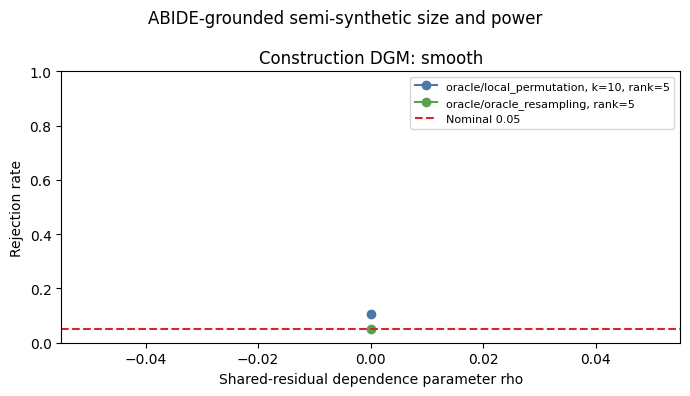


Semi-synthetic summary
construction_model generator_mode  calibration_mode  k_neighbors  shared_rank  rho  rejection_rate  median_p_value  mean_T_obs  median_T_obs  mean_fallback_fraction  mean_matched_z_distance  integration_pairs  candidate_integration_pairs  repetitions  rejection_mcse  rejection_wilson_low  rejection_wilson_high
            smooth         oracle local_permutation           10            5  0.0           0.105          0.3600    0.000958      0.000911                 0.02381                 1.024037               4096                        28056          200        0.021677              0.069707               0.155180
            smooth         oracle oracle_resampling            0            5  0.0           0.050          0.4975    0.000958      0.000911                     NaN                      NaN               4096                        28056          200        0.015411              0.027383               0.089578


,construction_model,generator_mode,calibration_mode,k_neighbors,shared_rank,rho,rejection_rate,median_p_value,mean_T_obs,median_T_obs,mean_fallback_fraction,mean_matched_z_distance,integration_pairs,candidate_integration_pairs,repetitions,rejection_mcse,rejection_wilson_low,rejection_wilson_high
0,smooth,oracle,local_permutation,10,5,0.0,0.105,0.3600,0.000958,0.000911,0.02381,1.024037,4096,28056,200,0.021677,0.069707,0.155180
1,smooth,oracle,oracle_resampling,0,5,0.0,0.050,0.4975,0.000958,0.000911,NaN,NaN,4096,28056,200,0.015411,0.027383,0.089578


In [8]:
# Uncomment after the quick neighborhood screen.
SELECTED_K = 10
NULL_PAPER_CONFIG = replace(
    CONFIG,
    quick_mode=False,
    semi_permutations_paper=199,
    max_integration_pairs_paper=4096,
    output_dir="/content/abide_spd_revised_v3_paper",
)
NULL_PAPER = run_null_calibration_diagnostics(
    NULL_PAPER_CONFIG,
    repetitions=200,
    construction_models=("smooth",),
    k_values=(SELECTED_K,),
)
NULL_PAPER

## Stage 2: intermediate smooth-DGM power run

Run only after null calibration is acceptable. This computationally lighter run uses 30 repetitions, 99 calibration replicates, `M=75`, and 4,096 integration pairs. It checks the shape of the power curves. Increase repetitions and Monte Carlo sizes only for the frozen final experiment.

[get_dataset_dir] Dataset found in /content/nilearn_data/ABIDE_pcp

Retained n=168; exclusions={'short_or_missing': 0, 'invalid_shape': 0, 'motion': 4, 'nonfinite': 0, 'constant_required_roi': 0}
Saved data to /content/abide_spd_revised_v3_paper

Construction model=smooth, OOF R2 X=0.037, Y=0.150

Semi-synthetic model=smooth, rank=5, rho=0.00
  rep 1/50, oracle/local_permutation, k=10: p=0.2200, fallback=0.024
  rep 1/50, oracle/oracle_resampling, k=NA: p=0.1200, fallback=NA
  rep 1/50, fitted/local_permutation, k=10: p=0.8500, fallback=0.024
  rep 2/50, oracle/local_permutation, k=10: p=0.9500, fallback=0.024
  rep 2/50, oracle/oracle_resampling, k=NA: p=0.7800, fallback=NA
  rep 2/50, fitted/local_permutation, k=10: p=1.0000, fallback=0.024
  rep 3/50, oracle/local_permutation, k=10: p=0.1800, fallback=0.024
  rep 3/50, oracle/oracle_resampling, k=NA: p=0.1300, fallback=NA
  rep 3/50, fitted/local_permutation, k=10: p=0.6100, fallback=0.024
  rep 4/50, oracle/local_permutation, k=10: p=0.8700, fallback=0.024
  rep 4/50, oracle/oracle_resampling, k=NA

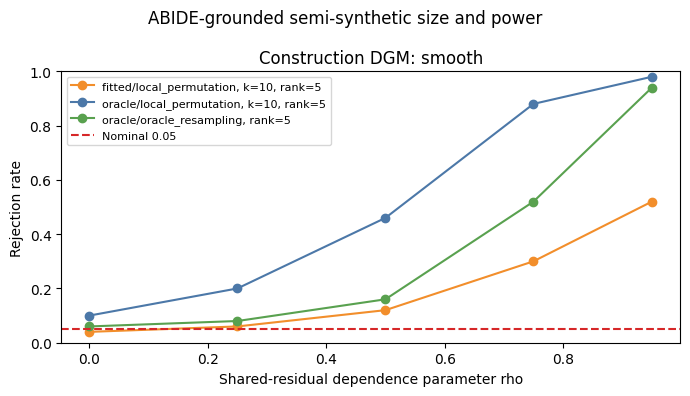


Semi-synthetic summary
construction_model generator_mode  calibration_mode  k_neighbors  shared_rank  rho  rejection_rate  median_p_value  mean_T_obs  median_T_obs  mean_fallback_fraction  mean_matched_z_distance  integration_pairs  candidate_integration_pairs  repetitions  rejection_mcse  rejection_wilson_low  rejection_wilson_high
            smooth         fitted local_permutation           10            5 0.00            0.04           0.550    0.001638      0.001530                 0.02381                 1.024397               4096                        28056           50        0.027713              0.011039               0.134601
            smooth         fitted local_permutation           10            5 0.25            0.06           0.600    0.001619      0.001481                 0.02381                 1.024397               4096                        28056           50        0.033586              0.020615               0.162171
            smooth         fitted local_

,construction_model,generator_mode,calibration_mode,k_neighbors,shared_rank,rho,rejection_rate,median_p_value,mean_T_obs,median_T_obs,mean_fallback_fraction,mean_matched_z_distance,integration_pairs,candidate_integration_pairs,repetitions,rejection_mcse,rejection_wilson_low,rejection_wilson_high
0,smooth,fitted,local_permutation,10,5,0.00,0.04,0.550,0.001638,0.001530,0.02381,1.024397,4096,28056,50,0.027713,0.011039,0.134601
1,smooth,fitted,local_permutation,10,5,0.25,0.06,0.600,0.001619,0.001481,0.02381,1.024397,4096,28056,50,0.033586,0.020615,0.162171
2,smooth,fitted,local_permutation,10,5,0.50,0.12,0.665,0.001595,0.001497,0.02381,1.024397,4096,28056,50,0.045957,0.056176,0.238048
3,smooth,fitted,local_permutation,10,5,0.75,0.30,0.420,0.001644,0.001536,0.02381,1.024397,4096,28056,50,0.064807,0.191036,0.437504
4,smooth,fitted,local_permutation,10,5,0.95,0.52,0.010,0.001844,0.001753,0.02381,1.024397,4096,28056,50,0.070654,0.385117,0.652029
5,smooth,oracle,local_permutation,10,5,0.00,0.10,0.445,0.000936,0.000880,0.02381,1.024397,4096,28056,50,0.042426,0.043476,0.213602
6,smooth,oracle,local_permutation,10,5,0.25,0.20,0.240,0.000991,0.000926,0.02381,1.024397,4096,28056,50,0.056569,0.112438,0.330371
7,smooth,oracle,local_permutation,10,5,0.50,0.46,0.060,0.001096,0.001006,0.02381,1.024397,4096,28056,50,0.070484,0.329697,0.596011
8,smooth,oracle,local_permutation,10,5,0.75,0.88,0.010,0.001316,0.001221,0.02381,1.024397,4096,28056,50,0.045957,0.761952,0.943824
9,smooth,oracle,local_permutation,10,5,0.95,0.98,0.010,0.001671,0.001584,0.02381,1.024397,4096,28056,50,0.019799,0.895046,0.996461


In [9]:
# Uncomment after passing the formal null-calibration gate.
POWER_CONFIG = replace(
    CONFIG,
    quick_mode=False,
    k_neighbors=SELECTED_K,
    m_profile_paper=75,
    semi_permutations_paper=99,
    max_integration_pairs_paper=4096,
    output_dir="/content/abide_spd_revised_v3_paper",
)
POWER_SMOOTH = run_semisynthetic_controls(
    POWER_CONFIG,
    repetitions=50,
    shared_ranks=(5,),
    construction_models=("smooth",),
    scenarios=(
        ("oracle", "local_permutation"),
        ("oracle", "oracle_resampling"),
        ("fitted", "local_permutation"),
    ),
    k_values=(SELECTED_K,),
    experiment_name="power_smooth_intermediate",
)
POWER_SMOOTH

## Random-forest DGM stress test

This preserves the earlier, less smooth construction mechanism. Run a smaller stress test after the smooth-DGM analysis is frozen. It is not used to choose `SELECTED_K`.

[get_dataset_dir] Dataset found in /content/nilearn_data/ABIDE_pcp

Retained n=168; exclusions={'short_or_missing': 0, 'invalid_shape': 0, 'motion': 4, 'nonfinite': 0, 'constant_required_roi': 0}
Saved data to /content/abide_spd_revised_v3_paper

Construction model=forest, OOF R2 X=0.009, Y=0.135

Semi-synthetic model=forest, rank=5, rho=0.00
  rep 1/20, oracle/local_permutation, k=10: p=0.6800, fallback=0.024
  rep 1/20, oracle/oracle_resampling, k=NA: p=0.3600, fallback=NA
  rep 1/20, fitted/local_permutation, k=10: p=0.1900, fallback=0.024
  rep 2/20, oracle/local_permutation, k=10: p=0.2000, fallback=0.024
  rep 2/20, oracle/oracle_resampling, k=NA: p=0.9200, fallback=NA
  rep 2/20, fitted/local_permutation, k=10: p=0.9300, fallback=0.024
  rep 3/20, oracle/local_permutation, k=10: p=0.0900, fallback=0.024
  rep 3/20, oracle/oracle_resampling, k=NA: p=0.2200, fallback=NA
  rep 3/20, fitted/local_permutation, k=10: p=0.1500, fallback=0.024
  rep 4/20, oracle/local_permutation, k=10: p=0.6000, fallback=0.024
  rep 4/20, oracle/oracle_resampling, k=NA

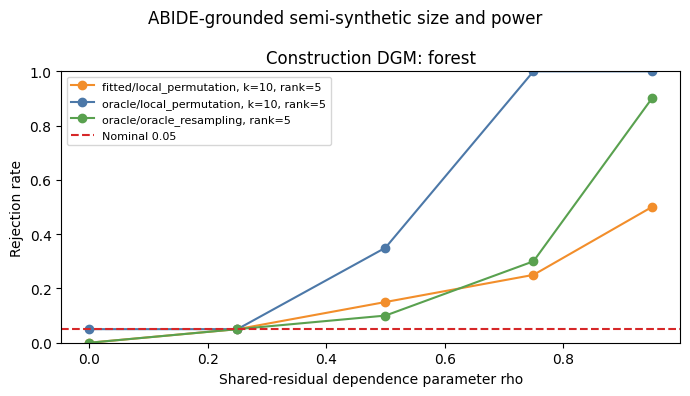


Semi-synthetic summary
construction_model generator_mode  calibration_mode  k_neighbors  shared_rank  rho  rejection_rate  median_p_value  mean_T_obs  median_T_obs  mean_fallback_fraction  mean_matched_z_distance  integration_pairs  candidate_integration_pairs  repetitions  rejection_mcse  rejection_wilson_low  rejection_wilson_high
            forest         fitted local_permutation           10            5 0.00            0.00           0.480    0.001427      0.001341                 0.02381                 1.024211               4096                        28056           20        0.000000              0.000000               0.161125
            forest         fitted local_permutation           10            5 0.25            0.05           0.340    0.001476      0.001425                 0.02381                 1.024211               4096                        28056           20        0.048734              0.008881               0.236131
            forest         fitted local_

,construction_model,generator_mode,calibration_mode,k_neighbors,shared_rank,rho,rejection_rate,median_p_value,mean_T_obs,median_T_obs,mean_fallback_fraction,mean_matched_z_distance,integration_pairs,candidate_integration_pairs,repetitions,rejection_mcse,rejection_wilson_low,rejection_wilson_high
0,forest,fitted,local_permutation,10,5,0.00,0.00,0.480,0.001427,0.001341,0.02381,1.024211,4096,28056,20,0.000000,0.000000,0.161125
1,forest,fitted,local_permutation,10,5,0.25,0.05,0.340,0.001476,0.001425,0.02381,1.024211,4096,28056,20,0.048734,0.008881,0.236131
2,forest,fitted,local_permutation,10,5,0.50,0.15,0.310,0.001575,0.001500,0.02381,1.024211,4096,28056,20,0.079844,0.052369,0.360419
3,forest,fitted,local_permutation,10,5,0.75,0.25,0.290,0.001663,0.001633,0.02381,1.024211,4096,28056,20,0.096825,0.111862,0.468701
4,forest,fitted,local_permutation,10,5,0.95,0.50,0.050,0.001788,0.001757,0.02381,1.024211,4096,28056,20,0.111803,0.299298,0.700702
5,forest,oracle,local_permutation,10,5,0.00,0.05,0.445,0.000984,0.000942,0.02381,1.024211,4096,28056,20,0.048734,0.008881,0.236131
6,forest,oracle,local_permutation,10,5,0.25,0.05,0.475,0.000971,0.000910,0.02381,1.024211,4096,28056,20,0.048734,0.008881,0.236131
7,forest,oracle,local_permutation,10,5,0.50,0.35,0.120,0.001048,0.000994,0.02381,1.024211,4096,28056,20,0.106654,0.181192,0.567146
8,forest,oracle,local_permutation,10,5,0.75,1.00,0.010,0.001237,0.001122,0.02381,1.024211,4096,28056,20,0.000000,0.838875,1.000000
9,forest,oracle,local_permutation,10,5,0.95,1.00,0.010,0.001485,0.001355,0.02381,1.024211,4096,28056,20,0.000000,0.838875,1.000000


In [10]:
# Uncomment after the smooth-DGM analysis is frozen.
STRESS_CONFIG = replace(
    POWER_CONFIG,
    output_dir="/content/abide_spd_revised_v3_paper",
)
POWER_FOREST = run_semisynthetic_controls(
    STRESS_CONFIG,
    repetitions=20,
    shared_ranks=(5,),
    construction_models=("forest",),
    scenarios=(
        ("oracle", "local_permutation"),
        ("oracle", "oracle_resampling"),
        ("fitted", "local_permutation"),
    ),
    k_values=(SELECTED_K,),
    experiment_name="power_forest_stress",
)
POWER_FOREST

## Stage 3: quick repeated-cross-fit real-data run

This smoke run uses two balanced split repetitions, `M=30`, and `B=49`. Splits are balanced globally and within diagnosis classes, including age and mean FD. It is only a pipeline check. Formal inference uses ten repeated splits and the fixed median-quantile aggregation rule.

In [ ]:
REAL_QUICK_CONFIG = replace(
    CONFIG,
    quick_mode=True,
    primary_male_only=True,
    primary_include_global_connectivity=False,
    k_neighbors=10,
    output_dir="/content/abide_spd_revised_v3_quick",
)
RESULTS_REAL_QUICK = run_revised_real_data(REAL_QUICK_CONFIG)
RESULTS_REAL_QUICK

## Formal repeated-cross-fit real-data run

This uses ten prespecified repeated splits, two folds per split, `M=150`, `B=999`, and 4,096 fixed integration pairs. Pair subsampling substantially reduces runtime while every fold still uses the same integration points for its observed and permutation statistics. Report the full split-level table and stability figure.

[get_dataset_dir] Dataset found in /content/nilearn_data/ABIDE_pcp

Retained n=168; exclusions={'short_or_missing': 0, 'invalid_shape': 0, 'motion': 4, 'nonfinite': 0, 'constant_required_roi': 0}
Saved data to /content/abide_spd_revised_v3_paper


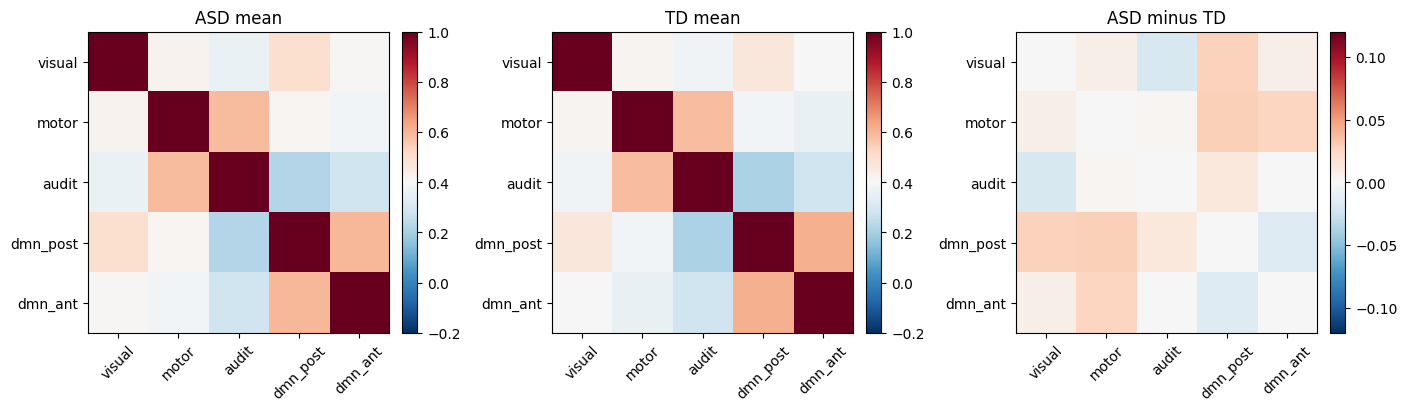


primary_connectome_diagnosis, split 1, fold 1: training n=66, analysis n=67
  completed 199/999 calibration replicates
  completed 398/999 calibration replicates
  completed 597/999 calibration replicates
  completed 796/999 calibration replicates
  completed 995/999 calibration replicates


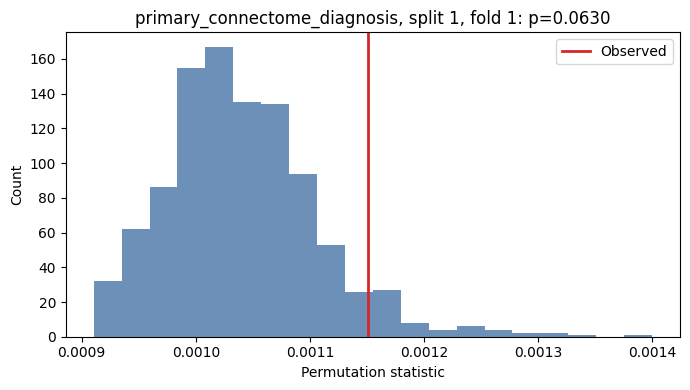

{
  "T_obs": 0.0011504900176078081,
  "p_value": 0.063,
  "reject_0.05": false,
  "mean_fallback_fraction": 0.0,
  "mean_matched_z_distance": 0.32288208774998123,
  "permutation_strategy": "min_cost",
  "calibration_mode": "local_permutation",
  "integration_pairs": 4096,
  "candidate_integration_pairs": 17822,
  "elapsed_seconds": 6.660048723220825,
  "device": "cuda",
  "analysis": "primary_connectome_diagnosis",
  "split": 1,
  "fold": 1,
  "n_training": 66,
  "n_analysis": 67,
  "M": 150,
  "B": 999,
  "k_neighbors": 10,
  "covariate_median_distance": 1.471454540048214,
  "balance_rms_smd": 0.036773287453553356,
  "balance_max_smd": 0.05028075305273172,
  "balance_within_class_max_smd": 0.07453393833702518,
  "balance_class_proportion_max_diff": 0.007914970601537785,
  "x_generator_multivariate_r2": 0.04280223955147544,
  "y_generator_log_loss": 0.6732054405952148,
  "y_generator_auc": 0.6571428571428571
}

primary_connectome_diagnosis, split 1, fold 2: training n=67, analysis n=66

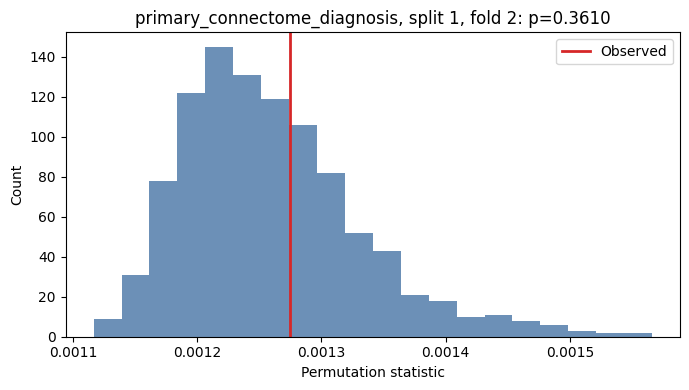

{
  "T_obs": 0.0012750657042488456,
  "p_value": 0.361,
  "reject_0.05": false,
  "mean_fallback_fraction": 0.0,
  "mean_matched_z_distance": 0.33687665462682187,
  "permutation_strategy": "min_cost",
  "calibration_mode": "local_permutation",
  "integration_pairs": 4096,
  "candidate_integration_pairs": 17292,
  "elapsed_seconds": 6.11237096786499,
  "device": "cuda",
  "analysis": "primary_connectome_diagnosis",
  "split": 1,
  "fold": 2,
  "n_training": 67,
  "n_analysis": 66,
  "M": 150,
  "B": 999,
  "k_neighbors": 10,
  "covariate_median_distance": 1.6275322674092345,
  "balance_rms_smd": 0.036773287453553356,
  "balance_max_smd": 0.05028075305273172,
  "balance_within_class_max_smd": 0.07453393833702518,
  "balance_class_proportion_max_diff": 0.007914970601537785,
  "x_generator_multivariate_r2": 0.023154486038476918,
  "y_generator_log_loss": 0.6650021520318311,
  "y_generator_auc": 0.6184331797235023
}

primary_connectome_diagnosis, split 2, fold 1: training n=66, analysis n=6

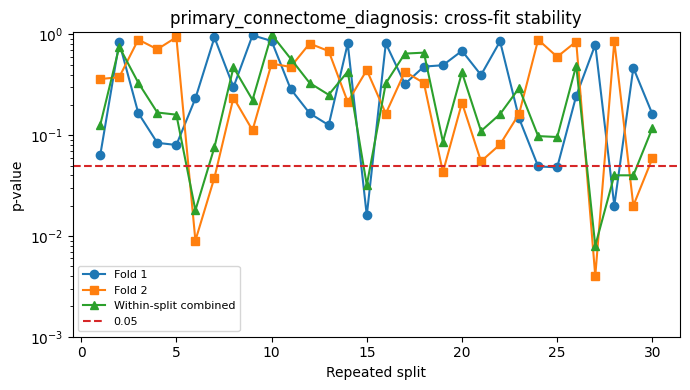


primary_connectome_diagnosis combined result
{
  "analysis": "primary_connectome_diagnosis",
  "p_value_repeated_crossfit": 0.448,
  "reject_0.05": false,
  "crossfit_repetitions": 30,
  "crossfit_quantile": 0.5,
  "median_split_p_value": 0.196,
  "minimum_split_p_value": 0.008,
  "maximum_split_p_value": 1.0,
  "split_p_values": [
    0.126,
    0.754,
    0.332,
    0.168,
    0.16,
    0.018,
    0.076,
    0.472,
    0.224,
    1.0,
    0.576,
    0.33,
    0.252,
    0.428,
    0.032,
    0.328,
    0.646,
    0.66,
    0.086,
    0.42,
    0.11,
    0.162,
    0.294,
    0.098,
    0.096,
    0.492,
    0.008,
    0.04,
    0.04,
    0.118
  ],
  "n_eligible": 133,
  "maximum_balance_rms_smd": 0.0807280112872724,
  "maximum_balance_within_class_smd": 0.15609488196256632
}

secondary_dmn_executive_given_salience, split 1, fold 1: training n=84, analysis n=84
  completed 199/999 calibration replicates
  completed 398/999 calibration replicates
  completed 597/999 calibration repli

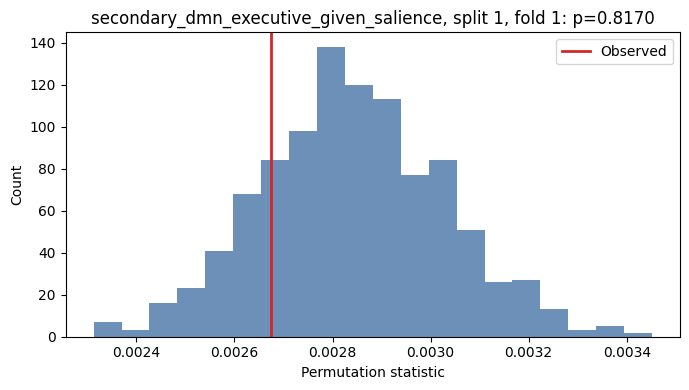

{
  "T_obs": 0.0026738194283097982,
  "p_value": 0.817,
  "reject_0.05": false,
  "mean_fallback_fraction": 0.011904761904761904,
  "mean_matched_z_distance": 1.081608587011549,
  "permutation_strategy": "min_cost",
  "calibration_mode": "local_permutation",
  "integration_pairs": 4096,
  "candidate_integration_pairs": 28056,
  "elapsed_seconds": 8.39492654800415,
  "device": "cuda",
  "analysis": "secondary_dmn_executive_given_salience",
  "split": 1,
  "fold": 1,
  "n_training": 84,
  "n_analysis": 84,
  "M": 150,
  "B": 999,
  "k_neighbors": 10,
  "z_spd_median_distance": 1.5407681876495274,
  "covariate_median_distance": 2.153447821153782,
  "balance_rms_smd": 0.12601764948459282,
  "balance_max_smd": 0.20519567041703068,
  "balance_within_class_max_smd": 0.3827705601873918,
  "balance_class_proportion_max_diff": 0.023809523809523836,
  "x_generator_multivariate_r2": -0.0006294840790099787,
  "y_generator_multivariate_r2": 0.05626281111369047
}

secondary_dmn_executive_given_salien

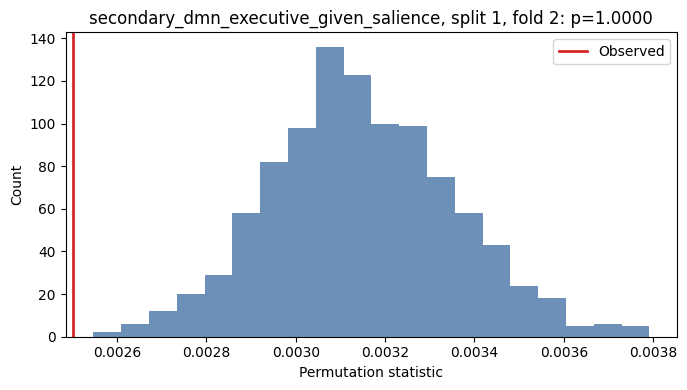

{
  "T_obs": 0.00250153592787683,
  "p_value": 1.0,
  "reject_0.05": false,
  "mean_fallback_fraction": 0.011904761904761904,
  "mean_matched_z_distance": 1.0122234281716054,
  "permutation_strategy": "min_cost",
  "calibration_mode": "local_permutation",
  "integration_pairs": 4096,
  "candidate_integration_pairs": 28056,
  "elapsed_seconds": 8.198225259780884,
  "device": "cuda",
  "analysis": "secondary_dmn_executive_given_salience",
  "split": 1,
  "fold": 2,
  "n_training": 84,
  "n_analysis": 84,
  "M": 150,
  "B": 999,
  "k_neighbors": 10,
  "z_spd_median_distance": 1.5767422662100183,
  "covariate_median_distance": 2.2517018093413856,
  "balance_rms_smd": 0.12601764948459282,
  "balance_max_smd": 0.20519567041703068,
  "balance_within_class_max_smd": 0.3827705601873918,
  "balance_class_proportion_max_diff": 0.023809523809523836,
  "x_generator_multivariate_r2": 0.007930926529622462,
  "y_generator_multivariate_r2": 0.05495663106045168
}

secondary_dmn_executive_given_salience,

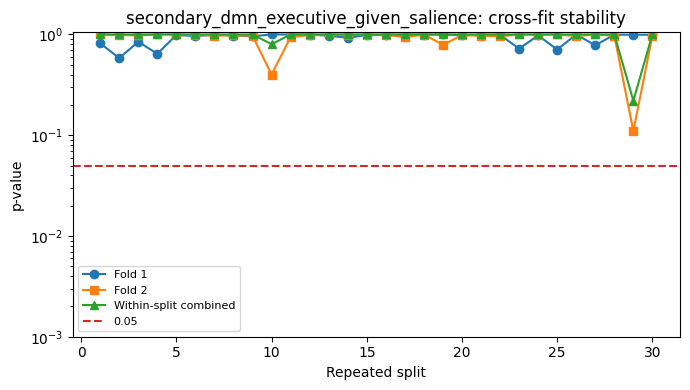


secondary_dmn_executive_given_salience combined result
{
  "analysis": "secondary_dmn_executive_given_salience",
  "p_value_repeated_crossfit": 1.0,
  "reject_0.05": false,
  "crossfit_repetitions": 30,
  "crossfit_quantile": 0.5,
  "median_split_p_value": 1.0,
  "minimum_split_p_value": 0.22,
  "maximum_split_p_value": 1.0,
  "split_p_values": [
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    0.8,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    0.22,
    1.0
  ],
  "n_eligible": 168,
  "maximum_balance_rms_smd": 0.13657556321289882,
  "maximum_balance_within_class_smd": 0.48089940710342804
}

Revised real-data summary
                              analysis  p_value_repeated_crossfit  reject_0.05  crossfit_repetitions  crossfit_quantile  median_split_p_value  minimum_split_p_value  maximum_split_p_value                              

,analysis,p_value_repeated_crossfit,reject_0.05,crossfit_repetitions,crossfit_quantile,median_split_p_value,minimum_split_p_value,maximum_split_p_value,split_p_values,n_eligible,maximum_balance_rms_smd,maximum_balance_within_class_smd
0,primary_connectome_diagnosis,0.448,False,30,0.5,0.196,0.008,1.0,"[0.126, 0.754, 0.332, 0.168, 0.16, 0.018, 0.07...",133,0.080728,0.156095
1,secondary_dmn_executive_given_salience,1.000,False,30,0.5,1.000,0.220,1.0,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",168,0.136576,0.480899


In [13]:
# Uncomment only after SELECTED_K has been frozen.
REAL_PAPER_CONFIG = replace(
    CONFIG,
    quick_mode=False,
    primary_male_only=True,
    primary_include_global_connectivity=False,
    k_neighbors=SELECTED_K,
    crossfit_repetitions_paper=30,
    crossfit_quantile=0.5,
    output_dir="/content/abide_spd_revised_v3_paper",
)
RESULTS_REAL_PAPER = run_revised_real_data(REAL_PAPER_CONFIG)
RESULTS_REAL_PAPER

## Prespecified all-sex sensitivity analysis

This version adds sex to the conditioning variables. It is secondary to the male-only primary analysis and should be reported regardless of direction.

[get_dataset_dir] Dataset found in /content/nilearn_data/ABIDE_pcp

Retained n=168; exclusions={'short_or_missing': 0, 'invalid_shape': 0, 'motion': 4, 'nonfinite': 0, 'constant_required_roi': 0}
Saved data to /content/abide_spd_revised_v3_all_sex


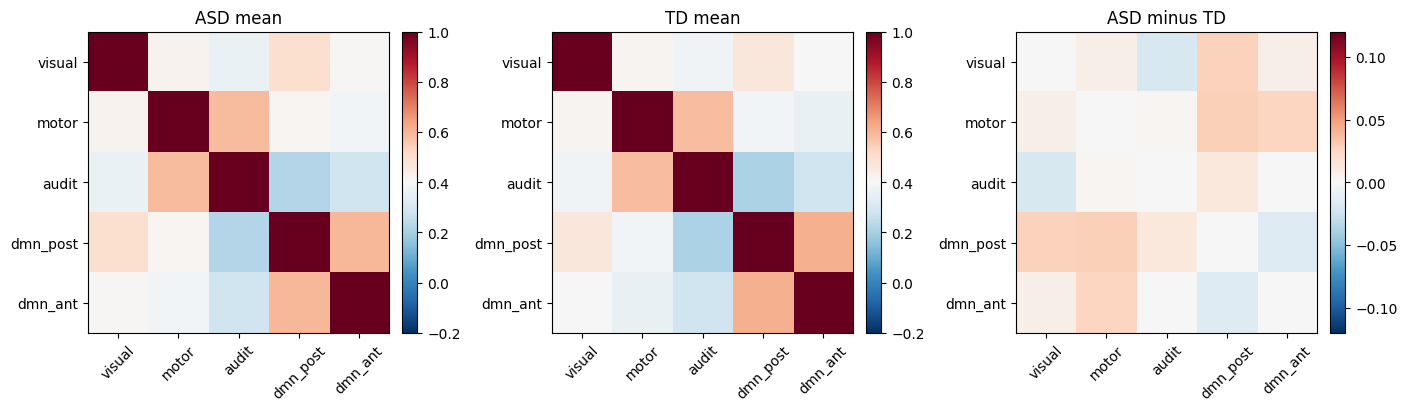


primary_connectome_diagnosis, split 1, fold 1: training n=84, analysis n=84
  completed 199/999 calibration replicates
  completed 398/999 calibration replicates
  completed 597/999 calibration replicates
  completed 796/999 calibration replicates
  completed 995/999 calibration replicates


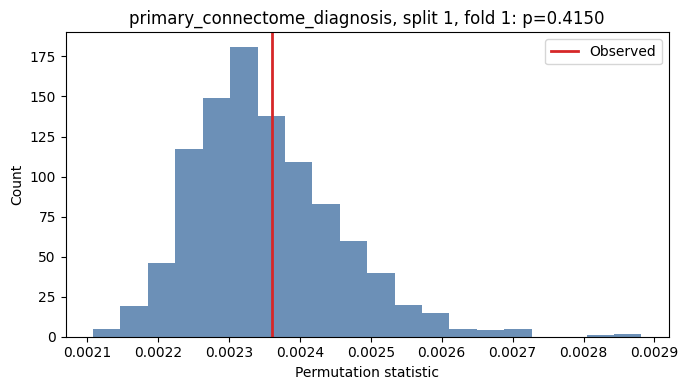

{
  "T_obs": 0.0023607308976352215,
  "p_value": 0.415,
  "reject_0.05": false,
  "mean_fallback_fraction": 0.0,
  "mean_matched_z_distance": 0.33910666441210546,
  "permutation_strategy": "min_cost",
  "calibration_mode": "local_permutation",
  "integration_pairs": 4096,
  "candidate_integration_pairs": 28056,
  "elapsed_seconds": 7.426246881484985,
  "device": "cuda",
  "analysis": "primary_connectome_diagnosis",
  "split": 1,
  "fold": 1,
  "n_training": 84,
  "n_analysis": 84,
  "M": 150,
  "B": 999,
  "k_neighbors": 10,
  "covariate_median_distance": 1.6258708970737272,
  "balance_rms_smd": 0.05631533459671548,
  "balance_max_smd": 0.029313667202432947,
  "balance_within_class_max_smd": 0.1025978352085154,
  "balance_class_proportion_max_diff": 0.0,
  "x_generator_multivariate_r2": -0.03695617656142769,
  "y_generator_log_loss": 0.6461997558196755,
  "y_generator_auc": 0.6533564814814815
}

primary_connectome_diagnosis, split 1, fold 2: training n=84, analysis n=84
  completed 199

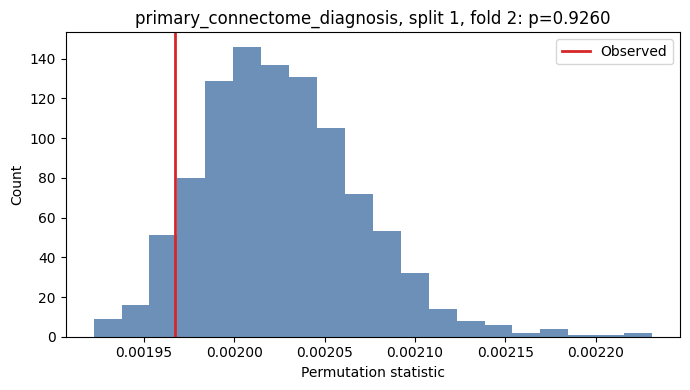

{
  "T_obs": 0.0019674389623105526,
  "p_value": 0.926,
  "reject_0.05": false,
  "mean_fallback_fraction": 0.0,
  "mean_matched_z_distance": 0.31936459426390557,
  "permutation_strategy": "min_cost",
  "calibration_mode": "local_permutation",
  "integration_pairs": 4096,
  "candidate_integration_pairs": 28056,
  "elapsed_seconds": 7.491769075393677,
  "device": "cuda",
  "analysis": "primary_connectome_diagnosis",
  "split": 1,
  "fold": 2,
  "n_training": 84,
  "n_analysis": 84,
  "M": 150,
  "B": 999,
  "k_neighbors": 10,
  "covariate_median_distance": 1.701887042698985,
  "balance_rms_smd": 0.05631533459671548,
  "balance_max_smd": 0.029313667202432947,
  "balance_within_class_max_smd": 0.1025978352085154,
  "balance_class_proportion_max_diff": 0.0,
  "x_generator_multivariate_r2": -0.009565276281311652,
  "y_generator_log_loss": 0.6492713679655137,
  "y_generator_auc": 0.6828703703703705
}

primary_connectome_diagnosis, split 2, fold 1: training n=84, analysis n=84
  completed 199

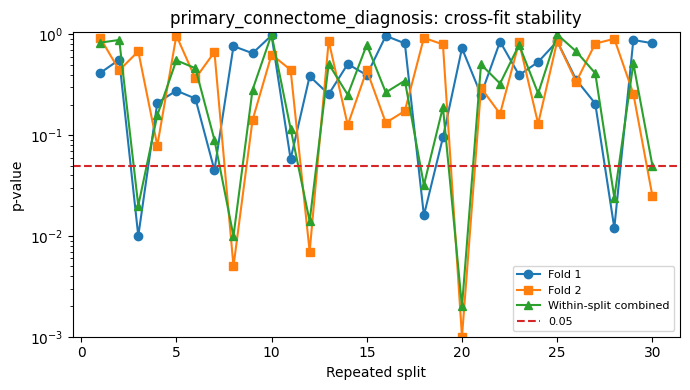


primary_connectome_diagnosis combined result
{
  "analysis": "primary_connectome_diagnosis",
  "p_value_repeated_crossfit": 0.652,
  "reject_0.05": false,
  "crossfit_repetitions": 30,
  "crossfit_quantile": 0.5,
  "median_split_p_value": 0.304,
  "minimum_split_p_value": 0.002,
  "maximum_split_p_value": 1.0,
  "split_p_values": [
    0.83,
    0.882,
    0.02,
    0.158,
    0.554,
    0.462,
    0.09,
    0.01,
    0.282,
    1.0,
    0.116,
    0.014,
    0.51,
    0.252,
    0.79,
    0.266,
    0.348,
    0.032,
    0.19,
    0.002,
    0.504,
    0.326,
    0.79,
    0.26,
    1.0,
    0.678,
    0.412,
    0.024,
    0.516,
    0.05
  ],
  "n_eligible": 168,
  "maximum_balance_rms_smd": 0.07202543432942456,
  "maximum_balance_within_class_smd": 0.14503165059414347
}

secondary_dmn_executive_given_salience, split 1, fold 1: training n=84, analysis n=84
  completed 199/999 calibration replicates
  completed 398/999 calibration replicates
  completed 597/999 calibration replicate

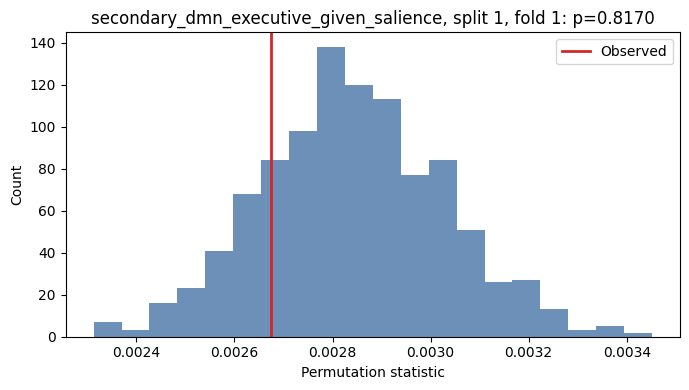

{
  "T_obs": 0.0026738194283097982,
  "p_value": 0.817,
  "reject_0.05": false,
  "mean_fallback_fraction": 0.011904761904761904,
  "mean_matched_z_distance": 1.081608587011549,
  "permutation_strategy": "min_cost",
  "calibration_mode": "local_permutation",
  "integration_pairs": 4096,
  "candidate_integration_pairs": 28056,
  "elapsed_seconds": 8.388914346694946,
  "device": "cuda",
  "analysis": "secondary_dmn_executive_given_salience",
  "split": 1,
  "fold": 1,
  "n_training": 84,
  "n_analysis": 84,
  "M": 150,
  "B": 999,
  "k_neighbors": 10,
  "z_spd_median_distance": 1.5407681876495274,
  "covariate_median_distance": 2.153447821153782,
  "balance_rms_smd": 0.12601764948459282,
  "balance_max_smd": 0.20519567041703068,
  "balance_within_class_max_smd": 0.3827705601873918,
  "balance_class_proportion_max_diff": 0.023809523809523836,
  "x_generator_multivariate_r2": -0.0006294840790099787,
  "y_generator_multivariate_r2": 0.05626281111369047
}

secondary_dmn_executive_given_salie

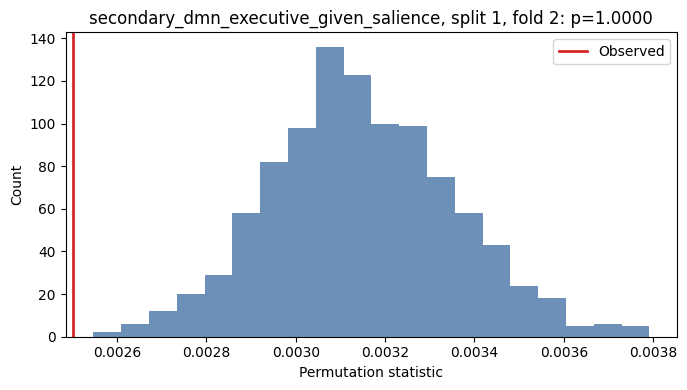

{
  "T_obs": 0.00250153592787683,
  "p_value": 1.0,
  "reject_0.05": false,
  "mean_fallback_fraction": 0.011904761904761904,
  "mean_matched_z_distance": 1.0122234281716054,
  "permutation_strategy": "min_cost",
  "calibration_mode": "local_permutation",
  "integration_pairs": 4096,
  "candidate_integration_pairs": 28056,
  "elapsed_seconds": 8.204814910888672,
  "device": "cuda",
  "analysis": "secondary_dmn_executive_given_salience",
  "split": 1,
  "fold": 2,
  "n_training": 84,
  "n_analysis": 84,
  "M": 150,
  "B": 999,
  "k_neighbors": 10,
  "z_spd_median_distance": 1.5767422662100183,
  "covariate_median_distance": 2.2517018093413856,
  "balance_rms_smd": 0.12601764948459282,
  "balance_max_smd": 0.20519567041703068,
  "balance_within_class_max_smd": 0.3827705601873918,
  "balance_class_proportion_max_diff": 0.023809523809523836,
  "x_generator_multivariate_r2": 0.007930926529622462,
  "y_generator_multivariate_r2": 0.05495663106045168
}

secondary_dmn_executive_given_salience,

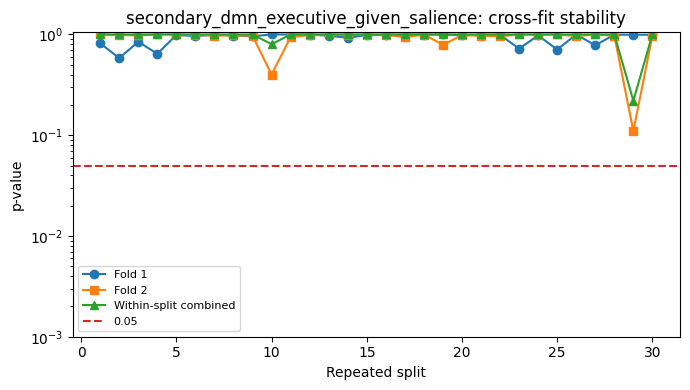


secondary_dmn_executive_given_salience combined result
{
  "analysis": "secondary_dmn_executive_given_salience",
  "p_value_repeated_crossfit": 1.0,
  "reject_0.05": false,
  "crossfit_repetitions": 30,
  "crossfit_quantile": 0.5,
  "median_split_p_value": 1.0,
  "minimum_split_p_value": 0.22,
  "maximum_split_p_value": 1.0,
  "split_p_values": [
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    0.8,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    0.22,
    1.0
  ],
  "n_eligible": 168,
  "maximum_balance_rms_smd": 0.13657556321289882,
  "maximum_balance_within_class_smd": 0.48089940710342804
}

Revised real-data summary
                              analysis  p_value_repeated_crossfit  reject_0.05  crossfit_repetitions  crossfit_quantile  median_split_p_value  minimum_split_p_value  maximum_split_p_value                              

,analysis,p_value_repeated_crossfit,reject_0.05,crossfit_repetitions,crossfit_quantile,median_split_p_value,minimum_split_p_value,maximum_split_p_value,split_p_values,n_eligible,maximum_balance_rms_smd,maximum_balance_within_class_smd
0,primary_connectome_diagnosis,0.652,False,30,0.5,0.304,0.002,1.0,"[0.83, 0.882, 0.02, 0.158, 0.554, 0.462, 0.09,...",168,0.072025,0.145032
1,secondary_dmn_executive_given_salience,1.000,False,30,0.5,1.000,0.220,1.0,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",168,0.136576,0.480899


In [15]:
# Uncomment after the primary formal run.
ALL_SEX_CONFIG = replace(
    REAL_PAPER_CONFIG,
    primary_male_only=False,
    output_dir="/content/abide_spd_revised_v3_all_sex",
)
RESULTS_ALL_SEX = run_revised_real_data(ALL_SEX_CONFIG)
RESULTS_ALL_SEX

## Download outputs

The archive contains the design JSON, processed SPD data, repeated balanced splits, all fold-level permutation arrays, split-level p-values, generator and matching diagnostics, calibration tables, and figures.

In [14]:
from google.colab import files
# !zip -qr /content/abide_spd_revised_v3_quick.zip /content/abide_spd_revised_v3_quick
# files.download("/content/abide_spd_revised_v3_quick.zip")

# Formal run:
!zip -qr /content/abide_spd_revised_v3_paper.zip /content/abide_spd_revised_v3_paper
files.download("/content/abide_spd_revised_v3_paper.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>